In [1]:
# Setup: imports, device, seeds
import os
import math
import random
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

try:
    import timm
except Exception as e:
    raise RuntimeError("Please install timm: pip install timm")

try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TFORMERS_AVAILABLE = True
except Exception:
    SENTENCE_TFORMERS_AVAILABLE = False

try:
    import faiss  # optional
    FAISS_AVAILABLE = True
except Exception:
    FAISS_AVAILABLE = False

try:
    from sklearn.metrics import f1_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Config
ROOT = "/home/saksham/coding/dl"
CSV_PATH = os.path.join(ROOT, "Dataset.csv")
IMAGES_ROOT = os.path.join(ROOT, "pooled_images")  # CSV paths like "images/..." are relative to pooled_images/

# Train on high-level categories (cookware, electronics, etc.)
# Model will also output fine-grained labels and attributes
CLASSIFICATION_MODE = 'coarse'  # Using coarse-grained training

# Training hyperparams (adjust as needed)
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0  # set >0 if numpy/torchvision available in worker processes
EPOCHS = 60  # for quick test; increase for better performance
BASE_LR = 1e-4
WEIGHT_DECAY = 5e-2
WARMUP_EPOCHS = 1
FREEZE_EPOCHS = 2  # freeze early for a few epochs

# Multitask loss weights
LAMBDA_ATTR = 0.5
LAMBDA_CONTR = 0.5
CONTR_TEMPERATURE = 0.07

# Retrieval embedding dimension
PROJ_DIM = 384

# Classification parameters - use ALL classes from dataset
USE_ALL_CLASSES = True  # Train on all classes in dataset
MIN_SAMPLES_PER_CLASS = 2  # Minimum samples per class for stratified split (lowered for inclusivity)

print({
    "csv": CSV_PATH,
    "use_all_classes": USE_ALL_CLASSES,
    "min_samples_per_class": MIN_SAMPLES_PER_CLASS,
    "epochs": EPOCHS,
    "bs": BATCH_SIZE,
    "img": IMG_SIZE,
})


{'csv': '/home/saksham/coding/dl/Dataset.csv', 'use_all_classes': True, 'min_samples_per_class': 2, 'epochs': 60, 'bs': 64, 'img': 224}


In [3]:
# DataFrame loading and vocab building

df = pd.read_csv(CSV_PATH)
if "Unnamed: 5" in df.columns:
    df = df.drop(columns=["Unnamed: 5"])  # empty column

print(f"📊 Loaded dataset: {len(df)} rows")

# Absolute image paths
def make_abs_path(rel_path: str) -> str:
    # Normalize Windows backslashes to forward slashes for cross-platform compatibility
    normalized_path = rel_path.replace("\\", "/")
    return os.path.join(IMAGES_ROOT, normalized_path)

df["abs_path"] = df["image_path"].apply(make_abs_path)

# Extract coarse (high-level) categories for training
def extract_coarse_class(label: str) -> str:
    """Extract high-level category (cookware, electronics, etc.)."""
    if not isinstance(label, str):
        return "unknown"
    label_clean = label.strip().lower().replace("-", "_")
    parts = [p for p in label_clean.split("_") if p]
    if not parts:
        return label_clean or "unknown"
    # handle patterns like "sports item" encoded as sports_item
    if len(parts) >= 2 and parts[0] in {"sports", "home", "daily"} and parts[1] in {"item", "items", "needs"}:
        return f"{parts[0]} {parts[1]}".strip()
    return parts[0]

# Apply coarse extraction for training
print("📦 Extracting COARSE categories from class labels...")
df["target_class"] = df["class_label"].apply(extract_coarse_class)

# Keep original fine-grained label for prediction/display
df["fine_label"] = df["class_label"].str.strip().str.lower().str.replace("-", "_")

# Filter classes based on minimum sample requirement
class_counts = df["target_class"].value_counts()
rare_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS]
if not rare_classes.empty:
    print(f"\n⚠️  Classes with fewer than {MIN_SAMPLES_PER_CLASS} samples (will be excluded):")
    for cls_name, count in rare_classes.items():
        print(f"  {cls_name}: {count}")

eligible_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()

if USE_ALL_CLASSES:
    # Use all eligible classes
    selected_classes = eligible_classes
    print(f"\n✅ Using ALL {len(selected_classes)} eligible classes (>= {MIN_SAMPLES_PER_CLASS} samples each)")
else:
    # Legacy mode: top-K classes (kept for backward compatibility)
    NUM_CLASSES_TARGET = 10
    selected_classes = eligible_classes[:NUM_CLASSES_TARGET]
    print(f"\n✅ Using top {len(selected_classes)} classes by frequency")

if not selected_classes:
    raise ValueError(f"No classes meet the minimum sample requirement ({MIN_SAMPLES_PER_CLASS}); please lower MIN_SAMPLES_PER_CLASS or inspect the dataset.")

df = df[df["target_class"].isin(selected_classes)].reset_index(drop=True)
print(f"\n📋 Selected classes ({len(selected_classes)}):", selected_classes[:10], "..." if len(selected_classes) > 10 else "")
print(f"📈 Filtered dataset size: {len(df)} rows")
print(f"\nPer-class distribution (top 20):")
print(df["target_class"].value_counts().head(20))

# ========================================
# DYNAMIC ATTRIBUTE PARSING
# Discover all unique attribute keys from the data
# ========================================
print("\n" + "="*60)
print("🔍 DYNAMIC ATTRIBUTE DISCOVERY")
print("="*60)

def parse_attributes_dynamic(attr_str: str) -> Dict[str, str]:
    """Dynamically parse all attributes from string without hardcoding keys."""
    values = {}
    if isinstance(attr_str, str) and attr_str.strip():
        parts = [p.strip() for p in attr_str.split(";") if p.strip()]
        for p in parts:
            if ":" in p:
                k, v = p.split(":", 1)
                k = k.strip().lower()
                v = v.strip().lower()
                values[k] = v if v else "unknown"
    return values

# Alias for backward compatibility
parse_attributes = parse_attributes_dynamic

# Parse all attributes
attr_rows = df["attributes"].apply(parse_attributes_dynamic)

# Discover all unique attribute keys
all_facet_keys = set()
for row in attr_rows:
    all_facet_keys.update(row.keys())

FACETS = sorted(all_facet_keys)
print(f"\n📌 Discovered {len(FACETS)} unique attribute facets:")
print(f"   {FACETS}")

# Normalize: ensure all rows have all facets (fill with 'unknown')
def normalize_attributes(attr_dict: Dict[str, str]) -> Dict[str, str]:
    return {facet: attr_dict.get(facet, "unknown") for facet in FACETS}

attr_rows = attr_rows.apply(normalize_attributes)

# Build facet vocabularies (include 'unknown')
facet_to_values: Dict[str, List[str]] = {}
for facet in FACETS:
    vals = sorted(set([row[facet] for row in attr_rows]))
    if "unknown" not in vals:
        vals = ["unknown"] + vals
    facet_to_values[facet] = vals

# Class label maps
# Coarse classes (for stratified split and primary classification)
coarse_classes = sorted(set(df["target_class"]))
coarse_to_id = {c: i for i, c in enumerate(coarse_classes)}
id_to_coarse = {i: c for c, i in coarse_to_id.items()}

# Fine-grained classes (all unique fine labels)
fine_classes = sorted(set(df["fine_label"]))
fine_to_id = {c: i for i, c in enumerate(fine_classes)}
id_to_fine = {i: c for c, i in fine_to_id.items()}

print(f"Coarse classes: {len(coarse_classes)}")
print(f"Fine-grained classes: {len(fine_classes)}")

from pathlib import Path
DATASET_TAG = f"{Path(CSV_PATH).stem}_{len(df)}_{len(coarse_classes)}c_{len(fine_classes)}f"
print("Checkpoint dataset tag:", DATASET_TAG)
# Keep backward compatibility
classes = coarse_classes
cls_to_id = coarse_to_id
id_to_cls = id_to_coarse

# Facet value maps
facet_to_id: Dict[str, Dict[str, int]] = {
    facet: {v: i for i, v in enumerate(values)} for facet, values in facet_to_values.items()
}
id_to_facet_value: Dict[str, Dict[int, str]] = {
    facet: {i: v for v, i in mapping.items()} for facet, mapping in facet_to_id.items()
}

print("Facet vocab sizes:")
for facet in FACETS:
    print(f"  {facet}: {len(facet_to_values[facet])} values -> {facet_to_values[facet]}")

# ========================================
# UNIFIED ATTRIBUTE APPROACH
# Treat class labels as additional attributes
# ========================================
print("\n" + "="*60)
print("🔄 UNIFIED ATTRIBUTE APPROACH")
print("   Treating class labels as attributes")
print("="*60)

# Extended facets including class labels
FACETS_UNIFIED = ["coarse_class", "fine_class", "color", "material", "condition", "size"]

# Build unified facet vocabularies
facet_to_values_unified: Dict[str, List[str]] = {
    "coarse_class": coarse_classes,
    "fine_class": fine_classes,
    "color": facet_to_values["color"],
    "material": facet_to_values["material"],
    "condition": facet_to_values["condition"],
    "size": facet_to_values["size"]
}

facet_to_id_unified: Dict[str, Dict[str, int]] = {
    facet: {v: i for i, v in enumerate(values)} 
    for facet, values in facet_to_values_unified.items()
}

id_to_facet_value_unified: Dict[str, Dict[int, str]] = {
    facet: {i: v for v, i in mapping.items()} 
    for facet, mapping in facet_to_id_unified.items()
}

print("\nUnified facet vocab sizes:")
for facet in FACETS_UNIFIED:
    print(f"  {facet}: {len(facet_to_values_unified[facet])} values")
print("="*60)

# ========================================
# HIERARCHICAL MAPPING: Coarse -> Fine Classes
# ========================================
print("\n🔗 Building hierarchical class mapping...")

# Build mapping from coarse class to valid fine classes
coarse_to_fine_mapping: Dict[str, List[str]] = {}
for coarse_class in coarse_classes:
    # Find all fine classes that belong to this coarse class
    fine_in_coarse = set()
    for fine_class in fine_classes:
        # Extract coarse part from fine class (e.g., "travel_bag" -> "travel")
        fine_coarse = extract_coarse_class(fine_class)
        if fine_coarse == coarse_class:
            fine_in_coarse.add(fine_class)
    coarse_to_fine_mapping[coarse_class] = sorted(fine_in_coarse)

print("\nHierarchical class structure:")
for coarse, fines in coarse_to_fine_mapping.items():
    print(f"  {coarse}: {len(fines)} fine classes")
    if len(fines) <= 5:
        print(f"    → {fines}")
    else:
        print(f"    → {fines[:3]} ... (+{len(fines)-3} more)")

# Create mapping from coarse_id to valid fine_ids
coarse_id_to_fine_ids: Dict[int, List[int]] = {}
for coarse_class, coarse_id in coarse_to_id.items():
    fine_classes_list = coarse_to_fine_mapping[coarse_class]
    fine_ids_list = [fine_to_id[fc] for fc in fine_classes_list]
    coarse_id_to_fine_ids[coarse_id] = fine_ids_list

print("\n✅ Hierarchical mapping created!")
print("="*60)



📊 Loaded dataset: 11880 rows
📦 Extracting COARSE categories from class labels...

✅ Using ALL 64 eligible classes (>= 2 samples each)

📋 Selected classes (64): ['clothing', 'personal', 'pen', 'tableware', 'electronics', 'stationery', 'footwear', 'travel', 'backpack', 'mouse'] ...
📈 Filtered dataset size: 11880 rows

Per-class distribution (top 20):
target_class
clothing       706
personal       672
pen            536
tableware      450
electronics    401
stationery     364
footwear       360
travel         360
backpack       360
mouse          358
stationary     355
sports         325
notebook       320
earphones      303
keyboard       300
sneakers       300
food           285
medical        281
bathroom       248
toothpaste     246
Name: count, dtype: int64

🔍 DYNAMIC ATTRIBUTE DISCOVERY

📌 Discovered 11 unique attribute facets:
   ['"color', 'color', 'colour', 'condition', 'conidition', 'features', 'material', 'pattern', 'shape', 'size', 'style']
Coarse classes: 64
Fine-grained clas

In [4]:
# Dataset and transforms
from PIL import Image
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MultiTaskDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, facet_to_id: Dict[str, Dict[str, int]], cls_to_id: Dict[str, int], fine_to_id: Dict[str, int], transform=None):
        self.frame = frame.reset_index(drop=True)
        self.facet_to_id = facet_to_id
        self.cls_to_id = cls_to_id
        self.fine_to_id = fine_to_id
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        image = Image.open(row["abs_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        coarse_id = self.cls_to_id[row["target_class"]]
        fine_id = self.fine_to_id[row["fine_label"]]
        attrs = parse_attributes(row["attributes"])
        facet_ids = {facet: self.facet_to_id[facet][attrs.get(facet, "unknown")] for facet in FACETS}
        caption = row.get("caption", "")
        return image, coarse_id, fine_id, facet_ids, caption, row.get("instance_id", "")

# Custom collate function to properly handle dictionary of facet_ids
def collate_multitask(batch):
    images = torch.stack([item[0] for item in batch])
    coarse_ids = [item[1] for item in batch]
    fine_ids = [item[2] for item in batch]
    facet_ids = [item[3] for item in batch]  # list of dicts
    captions = [item[4] for item in batch]
    inst_ids = [item[5] for item in batch]
    return images, coarse_ids, fine_ids, facet_ids, captions, inst_ids

# Train/Val/Test split (stratified by coarse class)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["target_class"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["target_class"])

train_set = MultiTaskDataset(train_df, facet_to_id, cls_to_id, fine_to_id, transform=train_transforms)
val_set = MultiTaskDataset(val_df, facet_to_id, cls_to_id, fine_to_id, transform=val_transforms)
test_set = MultiTaskDataset(test_df, facet_to_id, cls_to_id, fine_to_id, transform=val_transforms)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_multitask)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_multitask)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_multitask)

print(f"DataLoaders created with num_workers={NUM_WORKERS}")
print(f"Dataset sizes: train={len(train_set)}, val={len(val_set)}, test={len(test_set)}")
len(train_set), len(val_set), len(test_set)


DataLoaders created with num_workers=0
Dataset sizes: train=8316, val=1782, test=1782


(8316, 1782, 1782)

In [5]:
# ========================================
# UNIFIED ATTRIBUTE MODEL - Classes as Attributes
# ========================================

# Dataset for unified approach
class UnifiedAttributeDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, facet_to_id_unified: Dict[str, Dict[str, int]], transform=None):
        self.frame = frame.reset_index(drop=True)
        self.facet_to_id = facet_to_id_unified
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        image = Image.open(row["abs_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        
        # Parse all attributes including class labels
        attrs = parse_attributes(row["attributes"])
        facet_ids = {
            "coarse_class": self.facet_to_id["coarse_class"][row["target_class"]],
            "fine_class": self.facet_to_id["fine_class"][row["fine_label"]],
            "color": self.facet_to_id["color"][attrs.get("color", "unknown")],
            "material": self.facet_to_id["material"][attrs.get("material", "unknown")],
            "condition": self.facet_to_id["condition"][attrs.get("condition", "unknown")],
            "size": self.facet_to_id["size"][attrs.get("size", "unknown")]
        }
        
        caption = row.get("caption", "")
        return image, facet_ids, caption, row.get("instance_id", "")

# Collate function for unified approach
def collate_unified(batch):
    images = torch.stack([item[0] for item in batch])
    facet_ids = [item[1] for item in batch]  # list of dicts
    captions = [item[2] for item in batch]
    inst_ids = [item[3] for item in batch]
    return images, facet_ids, captions, inst_ids

# Create unified datasets
train_set_unified = UnifiedAttributeDataset(train_df, facet_to_id_unified, transform=train_transforms)
val_set_unified = UnifiedAttributeDataset(val_df, facet_to_id_unified, transform=val_transforms)
test_set_unified = UnifiedAttributeDataset(test_df, facet_to_id_unified, transform=val_transforms)

train_loader_unified = DataLoader(train_set_unified, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_unified)
val_loader_unified = DataLoader(val_set_unified, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_unified)
test_loader_unified = DataLoader(test_set_unified, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_unified)

print(f"✅ Unified DataLoaders created")
print(f"   Dataset sizes: train={len(train_set_unified)}, val={len(val_set_unified)}, test={len(test_set_unified)}")


✅ Unified DataLoaders created
   Dataset sizes: train=8316, val=1782, test=1782


In [6]:
# Unified Attribute Model - Only attribute heads, no separate classification
class UnifiedAttributeModel(nn.Module):
    def __init__(self, backbone_name: str, facet_to_id: Dict[str, Dict[str, int]], proj_dim: int = 384):
        super().__init__()
        self.backbone_name = backbone_name
        
        # Create backbone
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0, global_pool='avg')
        embed_dim = getattr(self.backbone, 'num_features', 192)
        self.embed_dim = embed_dim
        self.proj_dim = proj_dim

        # Only attribute heads - treating classes as attributes
        self.attr_heads = nn.ModuleDict({})
        for facet, mapping in facet_to_id.items():
            self.attr_heads[facet] = nn.Linear(embed_dim, len(mapping))

        # Image projection for retrieval
        self.img_proj = nn.Sequential(
            nn.Linear(embed_dim, proj_dim),
            nn.ReLU(inplace=True),
            nn.Linear(proj_dim, proj_dim)
        )

    def forward(self, x: torch.Tensor):
        feats = self.backbone(x)
        logits_attrs = {facet: head(feats) for facet, head in self.attr_heads.items()}
        img_emb = self.img_proj(feats)
        img_emb = F.normalize(img_emb, dim=-1)
        return feats, logits_attrs, img_emb

# Create unified model
model_unified = UnifiedAttributeModel(
    backbone_name='deit_tiny_patch16_224',
    facet_to_id=facet_to_id_unified,
    proj_dim=PROJ_DIM
).to(device)

print(f"✅ Unified model created")
print(f"   Backbone: DeiT-Tiny")
print(f"   Embed dim: {model_unified.embed_dim}")
print(f"   Attribute heads: {len(model_unified.attr_heads)}")
print(f"   Head sizes: ", {k: v.out_features for k, v in model_unified.attr_heads.items()})


Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


✅ Unified model created
   Backbone: DeiT-Tiny
   Embed dim: 192
   Attribute heads: 6
   Head sizes:  {'coarse_class': 64, 'fine_class': 186, 'color': 100, 'material': 35, 'condition': 15, 'size': 5}


In [7]:
# Losses, optimizer, and utilities

def cosine_warmup_lr(epoch, base_lr, warmup_epochs, total_epochs):
    if epoch < warmup_epochs:
        return base_lr * float(epoch + 1) / float(warmup_epochs)
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return base_lr * 0.5 * (1 + math.cos(math.pi * progress))


def compute_losses(logits_coarse, coarse_targets, logits_fine, fine_targets, logits_attrs: Dict[str, torch.Tensor], facet_targets: Dict[str, torch.Tensor]):
    loss_coarse = F.cross_entropy(logits_coarse, coarse_targets)
    loss_fine = F.cross_entropy(logits_fine, fine_targets)
    loss_attr = 0.0
    for facet, logits in logits_attrs.items():
        loss_attr = loss_attr + F.cross_entropy(logits, facet_targets[facet])
    loss_attr = loss_attr / max(1, len(logits_attrs))
    return loss_coarse, loss_fine, loss_attr


def contrastive_loss(img_emb: torch.Tensor, txt_emb: torch.Tensor, temperature: float = 0.07):
    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)
    logits = img_emb @ txt_emb.t() / temperature  # [B, B]
    targets = torch.arange(img_emb.size(0), device=img_emb.device)
    loss_i2t = F.cross_entropy(logits, targets)
    loss_t2i = F.cross_entropy(logits.t(), targets)
    return (loss_i2t + loss_t2i) * 0.5


# Optimizer
# Optimizer (legacy multi-head; only if `model` exists)
if 'model' in globals():
    optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
    frozen = False
else:
    # Unified models use optimizer_unified / optimizer_unified_tinyvit elsewhere
    optimizer = None
    scaler = None
    frozen = False


def set_backbone_trainable(module: nn.Module, trainable: bool):
    for p in module.parameters():
        p.requires_grad = trainable

# Metrics
@torch.no_grad()
def accuracy(pred: torch.Tensor, target: torch.Tensor) -> float:
    pred_labels = pred.argmax(dim=1)
    return (pred_labels == target).float().mean().item()

@torch.no_grad()
def macro_f1(pred: torch.Tensor, target: torch.Tensor) -> float:
    if not SKLEARN_AVAILABLE:
        return accuracy(pred, target)
    y_true = target.cpu().numpy()
    y_pred = pred.argmax(dim=1).cpu().numpy()
    return float(f1_score(y_true, y_pred, average='macro'))


In [8]:
# ✅ Dataset-scoped checkpoint helpers
from pathlib import Path

if 'CHECKPOINT_DIR' not in globals():
    CHECKPOINT_DIR = os.path.join(ROOT, 'checkpoints')

def _ckpt_subdir(dataset_tag: str) -> str:
    sub = os.path.join(CHECKPOINT_DIR, dataset_tag)
    Path(sub).mkdir(parents=True, exist_ok=True)
    return sub

def save_checkpoint(model, optimizer, epoch, metrics, model_name="model", best=False, dataset_tag: str = None):
    dataset_tag = dataset_tag or globals().get('DATASET_TAG', 'default')
    subdir = _ckpt_subdir(dataset_tag)
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else None,
        'metrics': metrics,
        'model_config': {
            'backbone_name': getattr(model, 'backbone_name', None),
            'embed_dim': getattr(model, 'embed_dim', None),
            'proj_dim': getattr(model, 'proj_dim', None),
            'dataset_tag': dataset_tag,
            'model_name': model_name,
        }
    }
    path = os.path.join(subdir, f"{model_name}_best.pt" if best else f"{model_name}_epoch_{epoch}.pt")
    torch.save(checkpoint, path)
    if best:
        print(f"💾 Saved best to {path}")
    return path

def load_checkpoint(model, optimizer=None, model_name="model", dataset_tag: str = None):
    dataset_tag = dataset_tag or globals().get('DATASET_TAG', 'default')
    subdir = _ckpt_subdir(dataset_tag)
    best_path = os.path.join(subdir, f"{model_name}_best.pt")
    if os.path.exists(best_path):
        print(f"📂 Loading checkpoint from {best_path}")
        checkpoint = torch.load(best_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        if optimizer is not None and checkpoint.get('optimizer_state_dict') is not None:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print(f"✅ Loaded epoch {checkpoint.get('epoch')} | metrics: {checkpoint.get('metrics')}")
        return True, checkpoint.get('epoch', 0), checkpoint.get('metrics', {})
    print(f"❌ No checkpoint at {best_path}")
    return False, 0, {}

def checkpoint_exists(model_name="model", dataset_tag: str = None):
    dataset_tag = dataset_tag or globals().get('DATASET_TAG', 'default')
    subdir = _ckpt_subdir(dataset_tag)
    return os.path.exists(os.path.join(subdir, f"{model_name}_best.pt"))

print(f"Checkpoint root: {CHECKPOINT_DIR} | dataset tag: {globals().get('DATASET_TAG','default')}")

Checkpoint root: /home/saksham/coding/dl/checkpoints | dataset tag: Dataset_11880_64c_186f


In [9]:
# Training and evaluation for unified approach

# Optimizer for unified model
optimizer_unified = torch.optim.AdamW(model_unified.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scaler_unified = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

@torch.no_grad()
def evaluate_unified(model: nn.Module, loader: DataLoader, facet_list: List[str], use_hierarchy: bool = True) -> Dict[str, float]:
    """Evaluate unified model treating classes as attributes."""
    model.eval()
    facet_accs = {facet: [] for facet in facet_list}
    facet_f1s = {facet: [] for facet in facet_list}
    fine_hier_accs = []  # Fine class accuracy with hierarchical constraint
    
    for images, facet_ids, captions, _ in loader:
        images = images.to(device, non_blocking=True)
        facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in facet_list}
        
        with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
            _, logits_attrs, _ = model(images)
        
        # Evaluate all facets normally
        for f in facet_list:
            facet_accs[f].append(accuracy(logits_attrs[f], facet_batch[f]))
            facet_f1s[f].append(macro_f1(logits_attrs[f], facet_batch[f]))
        
        # Evaluate fine class with hierarchical constraint
        if use_hierarchy:
            coarse_preds = logits_attrs["coarse_class"].argmax(dim=1)
            fine_probs = torch.softmax(logits_attrs["fine_class"], dim=1)
            fine_targets = facet_batch["fine_class"]
            
            correct = 0
            for i in range(len(coarse_preds)):
                coarse_id = coarse_preds[i].item()
                
                if coarse_id in coarse_id_to_fine_ids:
                    valid_fine_ids = coarse_id_to_fine_ids[coarse_id]
                    
                    # Mask and renormalize
                    masked_probs = torch.zeros_like(fine_probs[i])
                    masked_probs[valid_fine_ids] = fine_probs[i][valid_fine_ids]
                    
                    if masked_probs.sum() > 0:
                        fine_pred = masked_probs.argmax().item()
                    else:
                        fine_pred = fine_probs[i].argmax().item()
                else:
                    fine_pred = fine_probs[i].argmax().item()
                
                if fine_pred == fine_targets[i].item():
                    correct += 1
            
            fine_hier_accs.append(correct / len(coarse_preds))
    
    out = {}
    for f in facet_list:
        out[f'{f}_acc'] = float(np.mean(facet_accs[f])) if facet_accs[f] else 0.0
        out[f'{f}_f1'] = float(np.mean(facet_f1s[f])) if facet_f1s[f] else 0.0
    
    # Add hierarchical fine class accuracy
    if use_hierarchy and fine_hier_accs:
        out['fine_class_acc_hier'] = float(np.mean(fine_hier_accs))
    
    # Overall average
    all_accs = [out[f'{f}_acc'] for f in facet_list]
    out['avg_acc'] = float(np.mean(all_accs))
    
    return out

def hierarchical_consistency_loss(coarse_logits: torch.Tensor, fine_logits: torch.Tensor, 
                                   coarse_targets: torch.Tensor, fine_targets: torch.Tensor) -> torch.Tensor:
    """
    Compute hierarchical consistency loss.
    Encourages the model to only predict fine classes that are valid for the coarse class.
    """
    batch_size = coarse_logits.size(0)
    fine_probs = torch.softmax(fine_logits, dim=1)
    
    # Create a mask for valid fine classes given coarse class
    valid_mask = torch.zeros_like(fine_probs)
    
    for i in range(batch_size):
        coarse_id = coarse_targets[i].item()
        if coarse_id in coarse_id_to_fine_ids:
            valid_fine_ids = coarse_id_to_fine_ids[coarse_id]
            valid_mask[i, valid_fine_ids] = 1.0
    
    # Penalize probability mass on invalid fine classes
    invalid_prob_mass = (fine_probs * (1 - valid_mask)).sum(dim=1).mean()
    
    return invalid_prob_mass


def train_unified(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, 
                  optimizer, scaler, epochs: int = EPOCHS, model_name: str = "unified_model",
                  use_contrastive: bool = True, use_hierarchical_loss: bool = True):
    """Train unified model."""
    frozen = False
    best_val_avg_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        
        # Freeze/unfreeze strategy
        if (epoch < FREEZE_EPOCHS) and not frozen:
            set_backbone_trainable(model.backbone, False)
            for n, m in model.backbone.named_modules():
                if 'blocks' in n or 'fc' in n or 'head' in n:
                    set_backbone_trainable(m, True)
            for p in model.attr_heads.parameters(): p.requires_grad = True
            for p in model.img_proj.parameters(): p.requires_grad = True
        elif (epoch == FREEZE_EPOCHS) and not frozen:
            set_backbone_trainable(model.backbone, True)
            frozen = True

        # Adjust LR
        lr = cosine_warmup_lr(epoch, BASE_LR, WARMUP_EPOCHS, epochs)
        for g in optimizer.param_groups:
            g['lr'] = lr

        running = {"loss": 0.0, "loss_attr": 0.0, "loss_ctr": 0.0, "loss_hier": 0.0}
        prog_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for images, facet_ids, captions, _ in prog_bar:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}

            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, img_emb = model(images)
                
                # All attributes have equal weight
                loss_attr = 0.0
                for facet, logits in logits_attrs.items():
                    loss_attr = loss_attr + F.cross_entropy(logits, facet_batch[facet])
                loss_attr = loss_attr / len(logits_attrs)
                
                # Hierarchical consistency loss
                if use_hierarchical_loss:
                    loss_hier = hierarchical_consistency_loss(
                        logits_attrs["coarse_class"],
                        logits_attrs["fine_class"],
                        facet_batch["coarse_class"],
                        facet_batch["fine_class"]
                    )
                else:
                    loss_hier = torch.tensor(0.0, device=device)
                
                # Contrastive loss
                if use_contrastive and text_encoder is not None:
                    txt_emb = text_encoder.encode(list(captions))
                    loss_ctr = contrastive_loss(img_emb, txt_emb, temperature=CONTR_TEMPERATURE)
                else:
                    loss_ctr = torch.tensor(0.0, device=device)
                
                # Total loss
                loss = loss_attr + 0.5 * loss_hier + LAMBDA_CONTR * loss_ctr

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            running["loss"] += loss.item()
            running["loss_attr"] += loss_attr.item()
            running["loss_ctr"] += float(loss_ctr.item())
            running["loss_hier"] += float(loss_hier.item())

            prog_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "attr": f"{loss_attr.item():.4f}",
                "hier": f"{float(loss_hier.item()):.4f}",
                "ctr": f"{float(loss_ctr.item()):.4f}",
            })

        n_batches = max(1, len(train_loader))
        log = {k: v / n_batches for k, v in running.items()}
        val_metrics = evaluate_unified(model, val_loader, FACETS_UNIFIED, use_hierarchy=use_hierarchical_loss)
        
        print(f"Epoch {epoch+1:03d}/{epochs} LR {lr:.2e} | ", end="")
        print("train:", {k: round(v, 4) for k, v in log.items()})
        
        fine_acc_str = f"fine={val_metrics['fine_class_acc']:.4f}"
        if 'fine_class_acc_hier' in val_metrics:
            fine_acc_str += f"(hier={val_metrics['fine_class_acc_hier']:.4f})"
        
        print(f"  val: coarse={val_metrics['coarse_class_acc']:.4f} {fine_acc_str} " +
              f"color={val_metrics['color_acc']:.4f} material={val_metrics['material_acc']:.4f} " +
              f"avg={val_metrics['avg_acc']:.4f}")

        # Save if best
        if val_metrics['avg_acc'] > best_val_avg_acc:
            best_val_avg_acc = val_metrics['avg_acc']
            save_checkpoint(model, optimizer, epoch+1, val_metrics, model_name=model_name, best=True,dataset_tag=DATASET_TAG)
    
    print(f"\n✅ Training complete! Best avg val acc: {best_val_avg_acc:.4f}")
    return model

print("✅ Training functions ready for unified model")


✅ Training functions ready for unified model


/tmp/ipykernel_34868/2698944262.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_unified = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [10]:
# 🏋️ Load Unified DeiT Model (Classes as Attributes)

# Hardcoded checkpoint path
CHECKPOINT_PATH_DEIT = "/home/saksham/coding/dl/checkpoints/Dataset_11880_64c_186f/deit_unified_attr_best.pt"

print(f"📝 Loading DeiT model from: {CHECKPOINT_PATH_DEIT}")

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH_DEIT, map_location=device)
model_unified.load_state_dict(checkpoint['model_state_dict'])
if checkpoint.get('optimizer_state_dict') is not None:
    optimizer_unified.load_state_dict(checkpoint['optimizer_state_dict'])

print(f"✅ Loaded checkpoint from epoch {checkpoint.get('epoch')}")
print(f"   Metrics: {checkpoint.get('metrics')}")


📝 Loading DeiT model from: /home/saksham/coding/dl/checkpoints/Dataset_11880_64c_186f/deit_unified_attr_best.pt
✅ Loaded checkpoint from epoch 51
   Metrics: {'coarse_class_acc': 0.8419518853936877, 'coarse_class_f1': 0.7670491546170873, 'fine_class_acc': 0.8368262244122369, 'fine_class_f1': 0.7128291096581079, 'color_acc': 0.7778191140719822, 'color_f1': 0.5585681114765652, 'material_acc': 0.8150628315550941, 'material_f1': 0.6514040783382636, 'condition_acc': 0.8109499003205981, 'condition_f1': 0.6581430434917211, 'size_acc': 0.893353174839701, 'size_f1': 0.7746880173403097, 'fine_class_acc_hier': 0.8255621693121693, 'avg_acc': 0.8293271884322168}


In [11]:
# Helpers required by evaluate_unified
try:
    from sklearn.metrics import f1_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

@torch.no_grad()
def accuracy(pred: torch.Tensor, target: torch.Tensor) -> float:
    return (pred.argmax(dim=1) == target).float().mean().item()

@torch.no_grad()
def macro_f1(pred: torch.Tensor, target: torch.Tensor) -> float:
    if not SKLEARN_AVAILABLE:
        return accuracy(pred, target)
    y_true = target.detach().cpu().numpy()
    y_pred = pred.argmax(dim=1).detach().cpu().numpy()
    return float(f1_score(y_true, y_pred, average='macro'))

# Evaluate unified model on test set
test_metrics_unified = evaluate_unified(model_unified, test_loader_unified, FACETS_UNIFIED, use_hierarchy=True)

print("\n" + "="*70)
print("📊 UNIFIED MODEL TEST RESULTS (Classes as Attributes)")
print("="*70)
print(f"\n🎯 Classification Performance:")
print(f"   Coarse Class Accuracy: {test_metrics_unified['coarse_class_acc']:.4f}")
print(f"   Coarse Class F1:       {test_metrics_unified['coarse_class_f1']:.4f}")
print(f"   Fine Class Accuracy:   {test_metrics_unified['fine_class_acc']:.4f}")
print(f"   Fine Class F1:         {test_metrics_unified['fine_class_f1']:.4f}")
if 'fine_class_acc_hier' in test_metrics_unified:
    print(f"   Fine Class (Hierarchical): {test_metrics_unified['fine_class_acc_hier']:.4f} ⭐")

print(f"\n🏷️  Attribute Performance:")
print(f"   Color Accuracy:        {test_metrics_unified['color_acc']:.4f}  (F1: {test_metrics_unified['color_f1']:.4f})")
print(f"   Material Accuracy:     {test_metrics_unified['material_acc']:.4f}  (F1: {test_metrics_unified['material_f1']:.4f})")
print(f"   Condition Accuracy:    {test_metrics_unified['condition_acc']:.4f}  (F1: {test_metrics_unified['condition_f1']:.4f})")
print(f"   Size Accuracy:         {test_metrics_unified['size_acc']:.4f}  (F1: {test_metrics_unified['size_f1']:.4f})")

print(f"\n⭐ Overall Average Accuracy: {test_metrics_unified['avg_acc']:.4f}")
print("="*70)

/tmp/ipykernel_34868/2698944262.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarnin


📊 UNIFIED MODEL TEST RESULTS (Classes as Attributes)

🎯 Classification Performance:
   Coarse Class Accuracy: 0.8580
   Coarse Class F1:       0.7951
   Fine Class Accuracy:   0.8452
   Fine Class F1:         0.7229
   Fine Class (Hierarchical): 0.8385 ⭐

🏷️  Attribute Performance:
   Color Accuracy:        0.7721  (F1: 0.5361)
   Material Accuracy:     0.8203  (F1: 0.6637)
   Condition Accuracy:    0.8123  (F1: 0.6730)
   Size Accuracy:         0.8781  (F1: 0.7283)

⭐ Overall Average Accuracy: 0.8310


/tmp/ipykernel_34868/2698944262.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarnin

In [12]:
# 🔄 CREATE UNIFIED TINYVIT MODEL

# Create unified TinyVIT model
model_unified_tinyvit = UnifiedAttributeModel(
    backbone_name='tiny_vit_5m_224.dist_in22k_ft_in1k',
    facet_to_id=facet_to_id_unified,
    proj_dim=PROJ_DIM
).to(device)

print(f"✅ Unified TinyVIT model created")
print(f"   Backbone: TinyVIT-5M")
print(f"   Embed dim: {model_unified_tinyvit.embed_dim}")
print(f"   Attribute heads: {len(model_unified_tinyvit.attr_heads)}")
print(f"   Head sizes: ", {k: v.out_features for k, v in model_unified_tinyvit.attr_heads.items()})

# Optimizer for unified TinyVIT
optimizer_unified_tinyvit = torch.optim.AdamW(model_unified_tinyvit.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scaler_unified_tinyvit = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

print("✅ Optimizer and scaler ready for unified TinyVIT")


✅ Unified TinyVIT model created
   Backbone: TinyVIT-5M
   Embed dim: 320
   Attribute heads: 6
   Head sizes:  {'coarse_class': 64, 'fine_class': 186, 'color': 100, 'material': 35, 'condition': 15, 'size': 5}
✅ Optimizer and scaler ready for unified TinyVIT


/tmp/ipykernel_34868/3508383550.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_unified_tinyvit = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


In [13]:
# 🏋️ Load Unified TinyVIT Model

# Hardcoded checkpoint path
CHECKPOINT_PATH_TINYVIT = "/home/saksham/coding/dl/checkpoints/Dataset_11880_64c_186f/tinyvit_unified_attr_best.pt"

print(f"📝 Loading TinyVIT model from: {CHECKPOINT_PATH_TINYVIT}")

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH_TINYVIT, map_location=device)
model_unified_tinyvit.load_state_dict(checkpoint['model_state_dict'])
if checkpoint.get('optimizer_state_dict') is not None:
    optimizer_unified_tinyvit.load_state_dict(checkpoint['optimizer_state_dict'])

print(f"✅ Loaded checkpoint from epoch {checkpoint.get('epoch')}")
print(f"   Metrics: {checkpoint.get('metrics')}")


📝 Loading TinyVIT model from: /home/saksham/coding/dl/checkpoints/Dataset_11880_64c_186f/tinyvit_unified_attr_best.pt
✅ Loaded checkpoint from epoch 58
   Metrics: {'coarse_class_acc': 0.8762607468026025, 'coarse_class_f1': 0.8134854677550607, 'fine_class_acc': 0.8733672286782946, 'fine_class_f1': 0.7762526551845135, 'color_acc': 0.7512400788920266, 'color_f1': 0.46956155964935126, 'material_acc': 0.8078703710011074, 'material_f1': 0.6105075335383365, 'condition_acc': 0.802682706287929, 'condition_f1': 0.6455767768784139, 'size_acc': 0.8654513891254153, 'size_f1': 0.6949657851789005, 'fine_class_acc_hier': 0.855510085978836, 'avg_acc': 0.8294787534645627}


In [14]:
# Evaluate unified TinyVIT on test set
test_metrics_tinyvit = evaluate_unified(model_unified_tinyvit, test_loader_unified, FACETS_UNIFIED, use_hierarchy=True)

print("\n" + "="*70)
print("📊 UNIFIED TINYVIT TEST RESULTS")
print("="*70)
print(f"\n🎯 Classification Performance:")
print(f"   Coarse Class Accuracy: {test_metrics_tinyvit['coarse_class_acc']:.4f}")
print(f"   Coarse Class F1:       {test_metrics_tinyvit['coarse_class_f1']:.4f}")
print(f"   Fine Class Accuracy:   {test_metrics_tinyvit['fine_class_acc']:.4f}")
print(f"   Fine Class F1:         {test_metrics_tinyvit['fine_class_f1']:.4f}")
if 'fine_class_acc_hier' in test_metrics_tinyvit:
    print(f"   Fine Class (Hierarchical): {test_metrics_tinyvit['fine_class_acc_hier']:.4f} ⭐")

print(f"\n🏷️  Attribute Performance:")
print(f"   Color Accuracy:        {test_metrics_tinyvit['color_acc']:.4f}  (F1: {test_metrics_tinyvit['color_f1']:.4f})")
print(f"   Material Accuracy:     {test_metrics_tinyvit['material_acc']:.4f}  (F1: {test_metrics_tinyvit['material_f1']:.4f})")
print(f"   Condition Accuracy:    {test_metrics_tinyvit['condition_acc']:.4f}  (F1: {test_metrics_tinyvit['condition_f1']:.4f})")
print(f"   Size Accuracy:         {test_metrics_tinyvit['size_acc']:.4f}  (F1: {test_metrics_tinyvit['size_f1']:.4f})")

print(f"\n⭐ Overall Average Accuracy: {test_metrics_tinyvit['avg_acc']:.4f}")
print("="*70)


/tmp/ipykernel_34868/2698944262.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarnin


📊 UNIFIED TINYVIT TEST RESULTS

🎯 Classification Performance:
   Coarse Class Accuracy: 0.8836
   Coarse Class F1:       0.8323
   Fine Class Accuracy:   0.8832
   Fine Class F1:         0.7912
   Fine Class (Hierarchical): 0.8618 ⭐

🏷️  Attribute Performance:
   Color Accuracy:        0.7584  (F1: 0.4902)
   Material Accuracy:     0.8122  (F1: 0.6483)
   Condition Accuracy:    0.8077  (F1: 0.6198)
   Size Accuracy:         0.8661  (F1: 0.6942)

⭐ Overall Average Accuracy: 0.8352


/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/saksham/anaconda3/envs/model_training/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/home/saksham/anaconda3/env

In [15]:
# 📊 COMPARISON: Unified DeiT-Tiny vs Unified TinyVIT

print("\n" + "="*100)
print("🔥 MODEL COMPARISON: Unified DeiT-Tiny vs Unified TinyVIT")
print("="*100)

# ==================== Overall Metrics ====================
print(f"\n{'Metric':<35s} {'DeiT-Tiny':>18s} {'TinyVIT':>18s} {'Diff':>15s}")
print("-"*100)

# Classification Accuracy
print(f"{'Coarse Class Accuracy':<35s} {test_metrics_unified['coarse_class_acc']:>18.4f} {test_metrics_tinyvit['coarse_class_acc']:>18.4f} {test_metrics_tinyvit['coarse_class_acc']-test_metrics_unified['coarse_class_acc']:>+15.4f}")
print(f"{'Coarse Class F1':<35s} {test_metrics_unified['coarse_class_f1']:>18.4f} {test_metrics_tinyvit['coarse_class_f1']:>18.4f} {test_metrics_tinyvit['coarse_class_f1']-test_metrics_unified['coarse_class_f1']:>+15.4f}")
print()
print(f"{'Fine Class Accuracy':<35s} {test_metrics_unified['fine_class_acc']:>18.4f} {test_metrics_tinyvit['fine_class_acc']:>18.4f} {test_metrics_tinyvit['fine_class_acc']-test_metrics_unified['fine_class_acc']:>+15.4f}")
print(f"{'Fine Class F1':<35s} {test_metrics_unified['fine_class_f1']:>18.4f} {test_metrics_tinyvit['fine_class_f1']:>18.4f} {test_metrics_tinyvit['fine_class_f1']-test_metrics_unified['fine_class_f1']:>+15.4f}")

if 'fine_class_acc_hier' in test_metrics_unified and 'fine_class_acc_hier' in test_metrics_tinyvit:
    print(f"{'Fine Class (Hierarchical) Acc':<35s} {test_metrics_unified['fine_class_acc_hier']:>18.4f} {test_metrics_tinyvit['fine_class_acc_hier']:>18.4f} {test_metrics_tinyvit['fine_class_acc_hier']-test_metrics_unified['fine_class_acc_hier']:>+15.4f}")

print()
# Attribute Accuracy & F1
print(f"{'Color Accuracy':<35s} {test_metrics_unified['color_acc']:>18.4f} {test_metrics_tinyvit['color_acc']:>18.4f} {test_metrics_tinyvit['color_acc']-test_metrics_unified['color_acc']:>+15.4f}")
print(f"{'Color F1':<35s} {test_metrics_unified['color_f1']:>18.4f} {test_metrics_tinyvit['color_f1']:>18.4f} {test_metrics_tinyvit['color_f1']-test_metrics_unified['color_f1']:>+15.4f}")
print()
print(f"{'Material Accuracy':<35s} {test_metrics_unified['material_acc']:>18.4f} {test_metrics_tinyvit['material_acc']:>18.4f} {test_metrics_tinyvit['material_acc']-test_metrics_unified['material_acc']:>+15.4f}")
print(f"{'Material F1':<35s} {test_metrics_unified['material_f1']:>18.4f} {test_metrics_tinyvit['material_f1']:>18.4f} {test_metrics_tinyvit['material_f1']-test_metrics_unified['material_f1']:>+15.4f}")
print()
print(f"{'Condition Accuracy':<35s} {test_metrics_unified['condition_acc']:>18.4f} {test_metrics_tinyvit['condition_acc']:>18.4f} {test_metrics_tinyvit['condition_acc']-test_metrics_unified['condition_acc']:>+15.4f}")
print(f"{'Condition F1':<35s} {test_metrics_unified['condition_f1']:>18.4f} {test_metrics_tinyvit['condition_f1']:>18.4f} {test_metrics_tinyvit['condition_f1']-test_metrics_unified['condition_f1']:>+15.4f}")
print()
print(f"{'Size Accuracy':<35s} {test_metrics_unified['size_acc']:>18.4f} {test_metrics_tinyvit['size_acc']:>18.4f} {test_metrics_tinyvit['size_acc']-test_metrics_unified['size_acc']:>+15.4f}")
print(f"{'Size F1':<35s} {test_metrics_unified['size_f1']:>18.4f} {test_metrics_tinyvit['size_f1']:>18.4f} {test_metrics_tinyvit['size_f1']-test_metrics_unified['size_f1']:>+15.4f}")

print()
print(f"{'Overall Average Accuracy':<35s} {test_metrics_unified['avg_acc']:>18.4f} {test_metrics_tinyvit['avg_acc']:>18.4f} {test_metrics_tinyvit['avg_acc']-test_metrics_unified['avg_acc']:>+15.4f}")

print("="*100)

# Determine winner
if test_metrics_tinyvit['avg_acc'] > test_metrics_unified['avg_acc']:
    print(f"\n🏆 Winner: TinyVIT (better by {test_metrics_tinyvit['avg_acc']-test_metrics_unified['avg_acc']:.4f})")
elif test_metrics_unified['avg_acc'] > test_metrics_tinyvit['avg_acc']:
    print(f"\n🏆 Winner: DeiT-Tiny (better by {test_metrics_unified['avg_acc']-test_metrics_tinyvit['avg_acc']:.4f})")
else:
    print("\n🤝 Tie: Both models perform equally!")

print("="*100)


# ==================== Class-wise Breakdown ====================
print("\n" + "="*100)
print("📋 CLASS-WISE PERFORMANCE BREAKDOWN")
print("="*100)

from sklearn.metrics import accuracy_score, f1_score
import torch.nn.functional as F

def compute_classwise_metrics(model, loader, facet_name):
    """Compute per-class accuracy and F1 for a specific facet."""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, facet_ids, captions, _ in loader:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(images)
            
            preds = logits_attrs[facet_name].argmax(dim=1).cpu().numpy()
            targets = facet_batch[facet_name].cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(targets)
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # Get unique classes present in test set
    unique_classes = np.unique(all_targets)
    
    # Compute per-class metrics
    per_class_acc = {}
    per_class_f1 = {}
    
    for class_id in unique_classes:
        mask = all_targets == class_id
        if mask.sum() > 0:
            class_acc = (all_preds[mask] == class_id).mean()
            per_class_acc[class_id] = class_acc
            
            # F1 for this class (binary: this class vs all others)
            binary_targets = (all_targets == class_id).astype(int)
            binary_preds = (all_preds == class_id).astype(int)
            class_f1 = f1_score(binary_targets, binary_preds, zero_division=0)
            per_class_f1[class_id] = class_f1
    
    return per_class_acc, per_class_f1

# Compute class-wise metrics for coarse classes
print("\n🎯 COARSE CLASS BREAKDOWN:")
print("-"*100)

coarse_acc_deit, coarse_f1_deit = compute_classwise_metrics(model_unified, test_loader_unified, 'coarse_class')
coarse_acc_tiny, coarse_f1_tiny = compute_classwise_metrics(model_unified_tinyvit, test_loader_unified, 'coarse_class')

print(f"{'Class':<30s} {'DeiT Acc':>15s} {'DeiT F1':>15s} {'TinyVIT Acc':>15s} {'TinyVIT F1':>15s}")
print("-"*100)

for class_id in sorted(coarse_acc_deit.keys()):
    class_name = id_to_facet_value_unified['coarse_class'].get(class_id, f"Unknown_{class_id}")
    deit_acc = coarse_acc_deit.get(class_id, 0.0)
    deit_f1 = coarse_f1_deit.get(class_id, 0.0)
    tiny_acc = coarse_acc_tiny.get(class_id, 0.0)
    tiny_f1 = coarse_f1_tiny.get(class_id, 0.0)
    
    print(f"{class_name:<30s} {deit_acc:>15.4f} {deit_f1:>15.4f} {tiny_acc:>15.4f} {tiny_f1:>15.4f}")

# Compute class-wise metrics for fine classes (show top/bottom 10)
print("\n" + "="*100)
print("🔍 FINE CLASS BREAKDOWN (Top 10 Best & Worst for DeiT-Tiny):")
print("-"*100)

fine_acc_deit, fine_f1_deit = compute_classwise_metrics(model_unified, test_loader_unified, 'fine_class')
fine_acc_tiny, fine_f1_tiny = compute_classwise_metrics(model_unified_tinyvit, test_loader_unified, 'fine_class')

# Sort by DeiT accuracy
sorted_fine = sorted(fine_acc_deit.items(), key=lambda x: x[1], reverse=True)

print(f"{'Class':<40s} {'DeiT Acc':>12s} {'DeiT F1':>12s} {'TinyVIT Acc':>12s} {'TinyVIT F1':>12s}")
print("-"*100)

print("\n📈 TOP 10 BEST PERFORMING:")
for class_id, _ in sorted_fine[:10]:
    class_name = id_to_facet_value_unified['fine_class'].get(class_id, f"Unknown_{class_id}")
    deit_acc = fine_acc_deit.get(class_id, 0.0)
    deit_f1 = fine_f1_deit.get(class_id, 0.0)
    tiny_acc = fine_acc_tiny.get(class_id, 0.0)
    tiny_f1 = fine_f1_tiny.get(class_id, 0.0)
    
    print(f"{class_name:<40s} {deit_acc:>12.4f} {deit_f1:>12.4f} {tiny_acc:>12.4f} {tiny_f1:>12.4f}")

print("\n📉 BOTTOM 10 WORST PERFORMING:")
for class_id, _ in sorted_fine[-10:]:
    class_name = id_to_facet_value_unified['fine_class'].get(class_id, f"Unknown_{class_id}")
    deit_acc = fine_acc_deit.get(class_id, 0.0)
    deit_f1 = fine_f1_deit.get(class_id, 0.0)
    tiny_acc = fine_acc_tiny.get(class_id, 0.0)
    tiny_f1 = fine_f1_tiny.get(class_id, 0.0)
    
    print(f"{class_name:<40s} {deit_acc:>12.4f} {deit_f1:>12.4f} {tiny_acc:>12.4f} {tiny_f1:>12.4f}")

print("="*100)



🔥 MODEL COMPARISON: Unified DeiT-Tiny vs Unified TinyVIT

Metric                                       DeiT-Tiny            TinyVIT            Diff
----------------------------------------------------------------------------------------------------
Coarse Class Accuracy                           0.8580             0.8836         +0.0256
Coarse Class F1                                 0.7951             0.8323         +0.0372

Fine Class Accuracy                             0.8452             0.8832         +0.0380
Fine Class F1                                   0.7229             0.7912         +0.0684
Fine Class (Hierarchical) Acc                   0.8385             0.8618         +0.0233

Color Accuracy                                  0.7721             0.7584         -0.0137
Color F1                                        0.5361             0.4902         -0.0459

Material Accuracy                               0.8203             0.8122         -0.0080
Material F1                

/tmp/ipykernel_34868/2693040673.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_34868/2693040673.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Class                                 DeiT Acc         DeiT F1     TinyVIT Acc      TinyVIT F1
----------------------------------------------------------------------------------------------------
backpack                                0.9630          0.9043          0.9074          0.9074
bathroom                                0.6486          0.6316          0.7027          0.6933
bottle                                  0.9259          0.9091          0.9630          0.9286
brush                                   0.7778          0.8750          0.8889          0.9412
calculator                              0.6667          0.8000          0.7778          0.7778
cap                                     1.0000          0.8780          0.9444          0.9444
clothing                                0.8491          0.8182          0.9057          0.8767
comb                                    0.8235          0.8750          0.9412          0.9412
cosmetics                               0.55

/tmp/ipykernel_34868/2693040673.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_34868/2693040673.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Class                                        DeiT Acc      DeiT F1  TinyVIT Acc   TinyVIT F1
----------------------------------------------------------------------------------------------------

📈 TOP 10 BEST PERFORMING:
bathroom_bucket                                1.0000       0.8000       1.0000       0.8889
bathroom_comb                                  1.0000       1.0000       1.0000       1.0000
bathroom_razor                                 1.0000       0.8000       0.5000       0.6667
bathroom_tap                                   1.0000       0.6667       1.0000       1.0000
bathroom_toothpaste                            1.0000       0.5000       1.0000       1.0000
cap                                            1.0000       0.8780       0.9444       0.9189
clothing_socks                                 1.0000       1.0000       1.0000       0.5000
clothing_spectacles                            1.0000       1.0000       1.0000       1.0000
clothing_trousers                  

Extracting embeddings for visualization...


/tmp/ipykernel_34868/733299306.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


Extracted 1782 samples for visualization
Applying PCA...
Applying t-SNE (this may take a minute)...


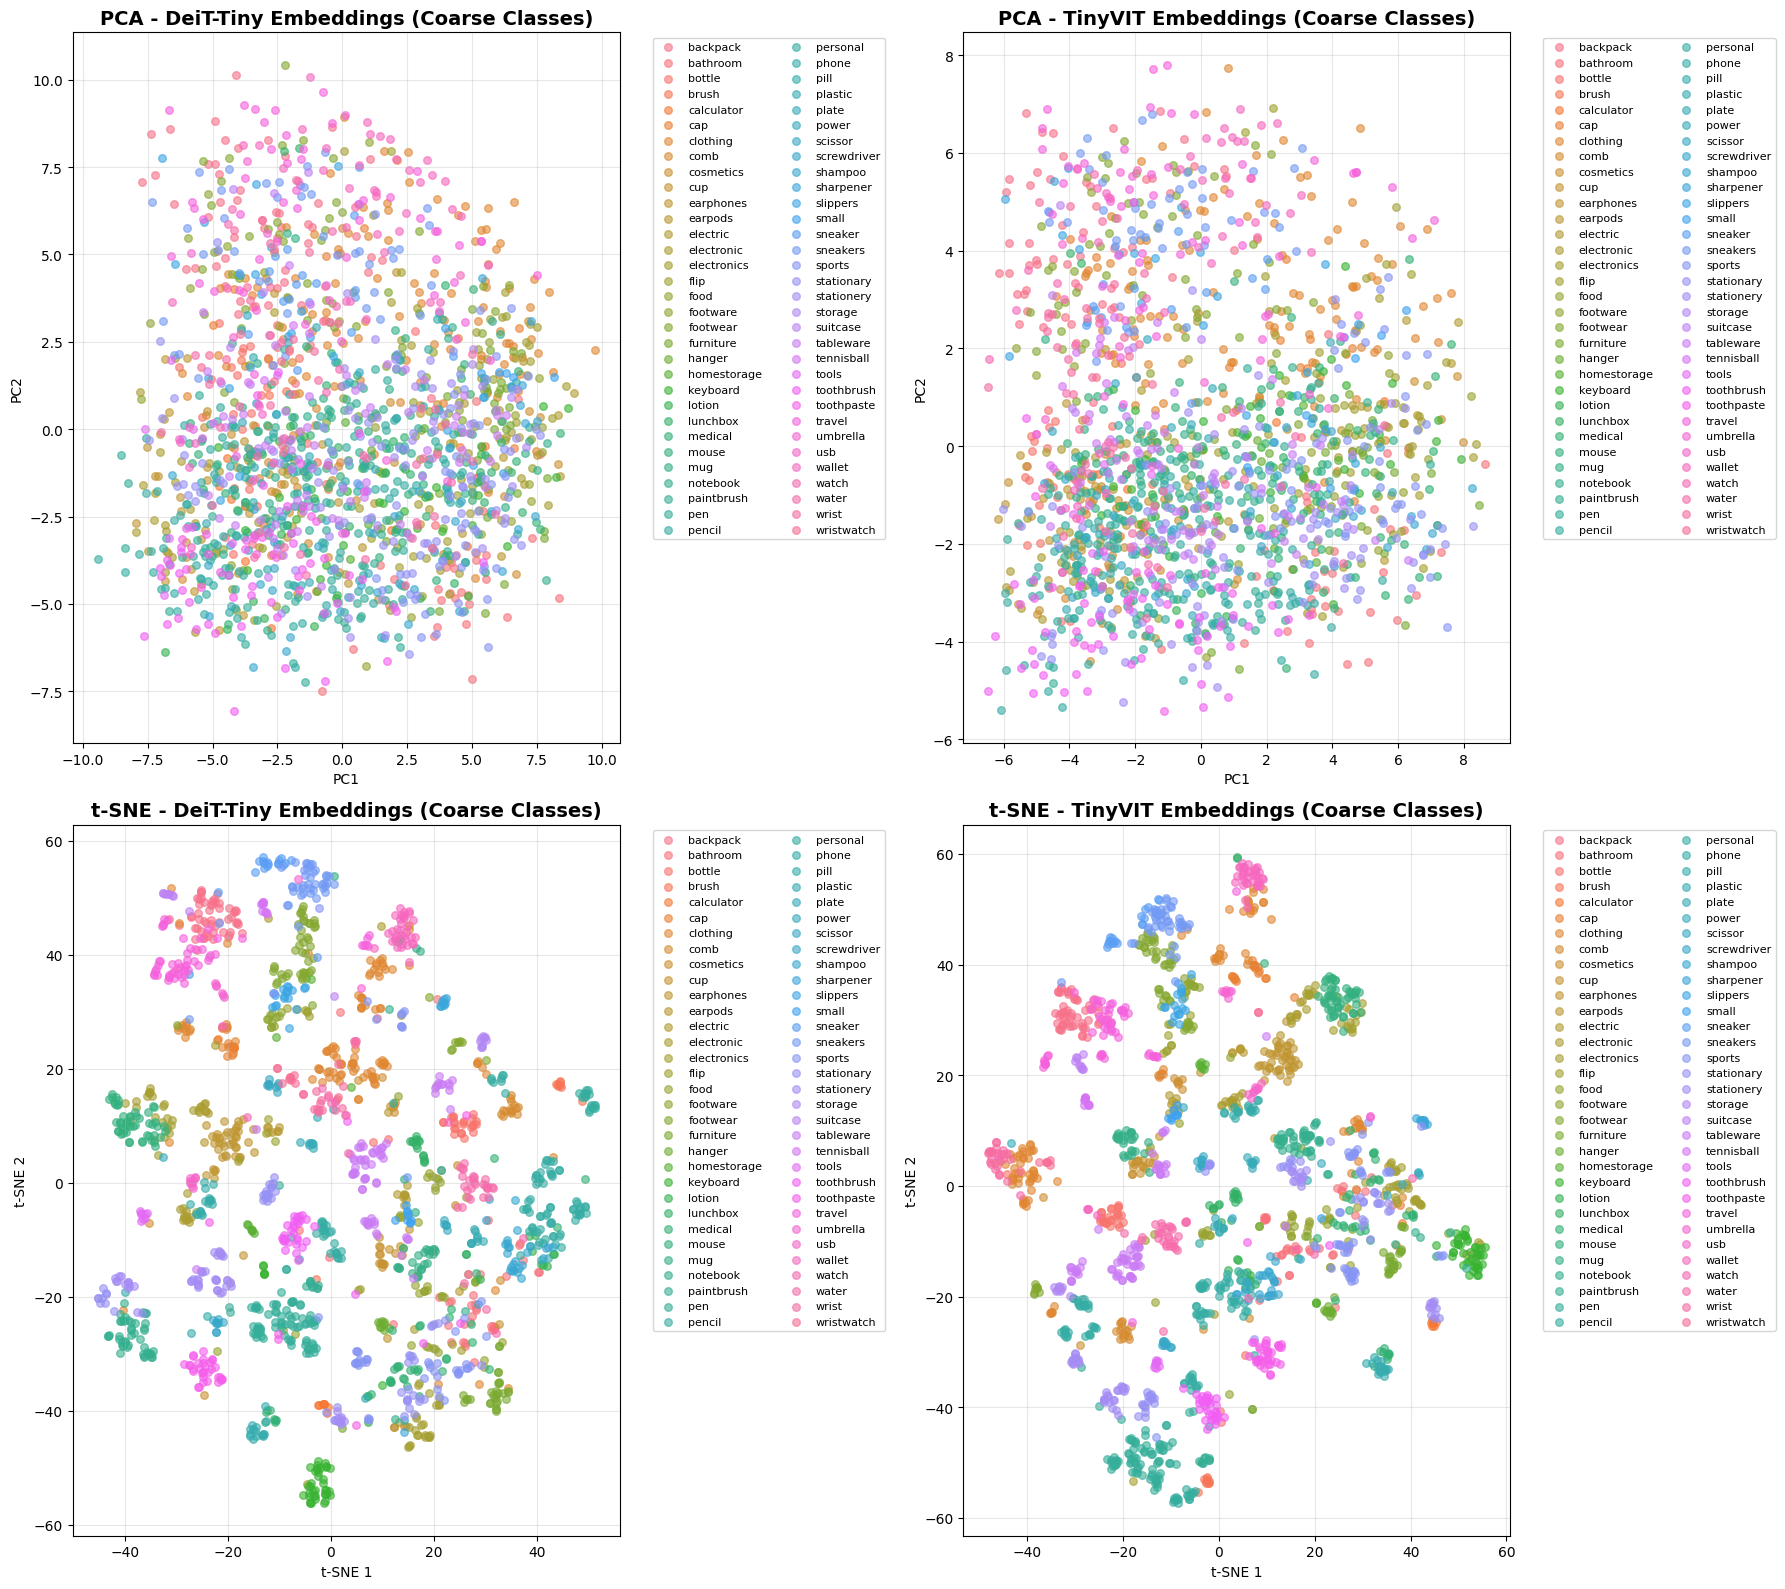

✅ Embedding visualizations complete!


In [16]:
# 📊 T-SNE & PCA Visualization - Embedding Space Analysis

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting embeddings for visualization...")

def extract_embeddings(model, loader, max_samples=2000):
    """Extract embeddings and labels from model."""
    model.eval()
    embeddings = []
    coarse_labels = []
    fine_labels = []
    
    count = 0
    with torch.no_grad():
        for images, facet_ids, _, _ in loader:
            if count >= max_samples:
                break
            
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                feats, _, _ = model(images)
            
            embeddings.append(feats.cpu().numpy())
            coarse_labels.extend(facet_batch['coarse_class'].cpu().numpy())
            fine_labels.extend(facet_batch['fine_class'].cpu().numpy())
            
            count += len(images)
    
    embeddings = np.vstack(embeddings)
    return embeddings, np.array(coarse_labels), np.array(fine_labels)

# Extract embeddings from both models
emb_deit, coarse_deit, fine_deit = extract_embeddings(model_unified, test_loader_unified, max_samples=2000)
emb_tiny, coarse_tiny, fine_tiny = extract_embeddings(model_unified_tinyvit, test_loader_unified, max_samples=2000)

print(f"Extracted {len(emb_deit)} samples for visualization")

# Apply PCA
print("Applying PCA...")
pca = PCA(n_components=2, random_state=42)
emb_pca_deit = pca.fit_transform(emb_deit)
emb_pca_tiny = pca.fit_transform(emb_tiny)

# Apply t-SNE
print("Applying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
emb_tsne_deit = tsne.fit_transform(emb_deit)

tsne2 = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
emb_tsne_tiny = tsne2.fit_transform(emb_tiny)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Get coarse class names and create color palette
unique_coarse = np.unique(coarse_deit)
num_classes = len(unique_coarse)
colors = sns.color_palette("husl", num_classes)
class_to_color = {cls: colors[i] for i, cls in enumerate(unique_coarse)}

# PCA - DeiT
ax = axes[0, 0]
for cls in unique_coarse:
    mask = coarse_deit == cls
    class_name = id_to_facet_value_unified['coarse_class'].get(cls, f"Class_{cls}")
    ax.scatter(emb_pca_deit[mask, 0], emb_pca_deit[mask, 1], 
               c=[class_to_color[cls]], label=class_name, alpha=0.6, s=30)
ax.set_title("PCA - DeiT-Tiny Embeddings (Coarse Classes)", fontsize=14, fontweight='bold')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# PCA - TinyVIT
ax = axes[0, 1]
for cls in unique_coarse:
    mask = coarse_tiny == cls
    class_name = id_to_facet_value_unified['coarse_class'].get(cls, f"Class_{cls}")
    ax.scatter(emb_pca_tiny[mask, 0], emb_pca_tiny[mask, 1], 
               c=[class_to_color[cls]], label=class_name, alpha=0.6, s=30)
ax.set_title("PCA - TinyVIT Embeddings (Coarse Classes)", fontsize=14, fontweight='bold')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# t-SNE - DeiT
ax = axes[1, 0]
for cls in unique_coarse:
    mask = coarse_deit == cls
    class_name = id_to_facet_value_unified['coarse_class'].get(cls, f"Class_{cls}")
    ax.scatter(emb_tsne_deit[mask, 0], emb_tsne_deit[mask, 1], 
               c=[class_to_color[cls]], label=class_name, alpha=0.6, s=30)
ax.set_title("t-SNE - DeiT-Tiny Embeddings (Coarse Classes)", fontsize=14, fontweight='bold')
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# t-SNE - TinyVIT
ax = axes[1, 1]
for cls in unique_coarse:
    mask = coarse_tiny == cls
    class_name = id_to_facet_value_unified['coarse_class'].get(cls, f"Class_{cls}")
    ax.scatter(emb_tsne_tiny[mask, 0], emb_tsne_tiny[mask, 1], 
               c=[class_to_color[cls]], label=class_name, alpha=0.6, s=30)
ax.set_title("t-SNE - TinyVIT Embeddings (Coarse Classes)", fontsize=14, fontweight='bold')
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Embedding visualizations complete!")


Generating confusion matrices...


/tmp/ipykernel_34868/287899780.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


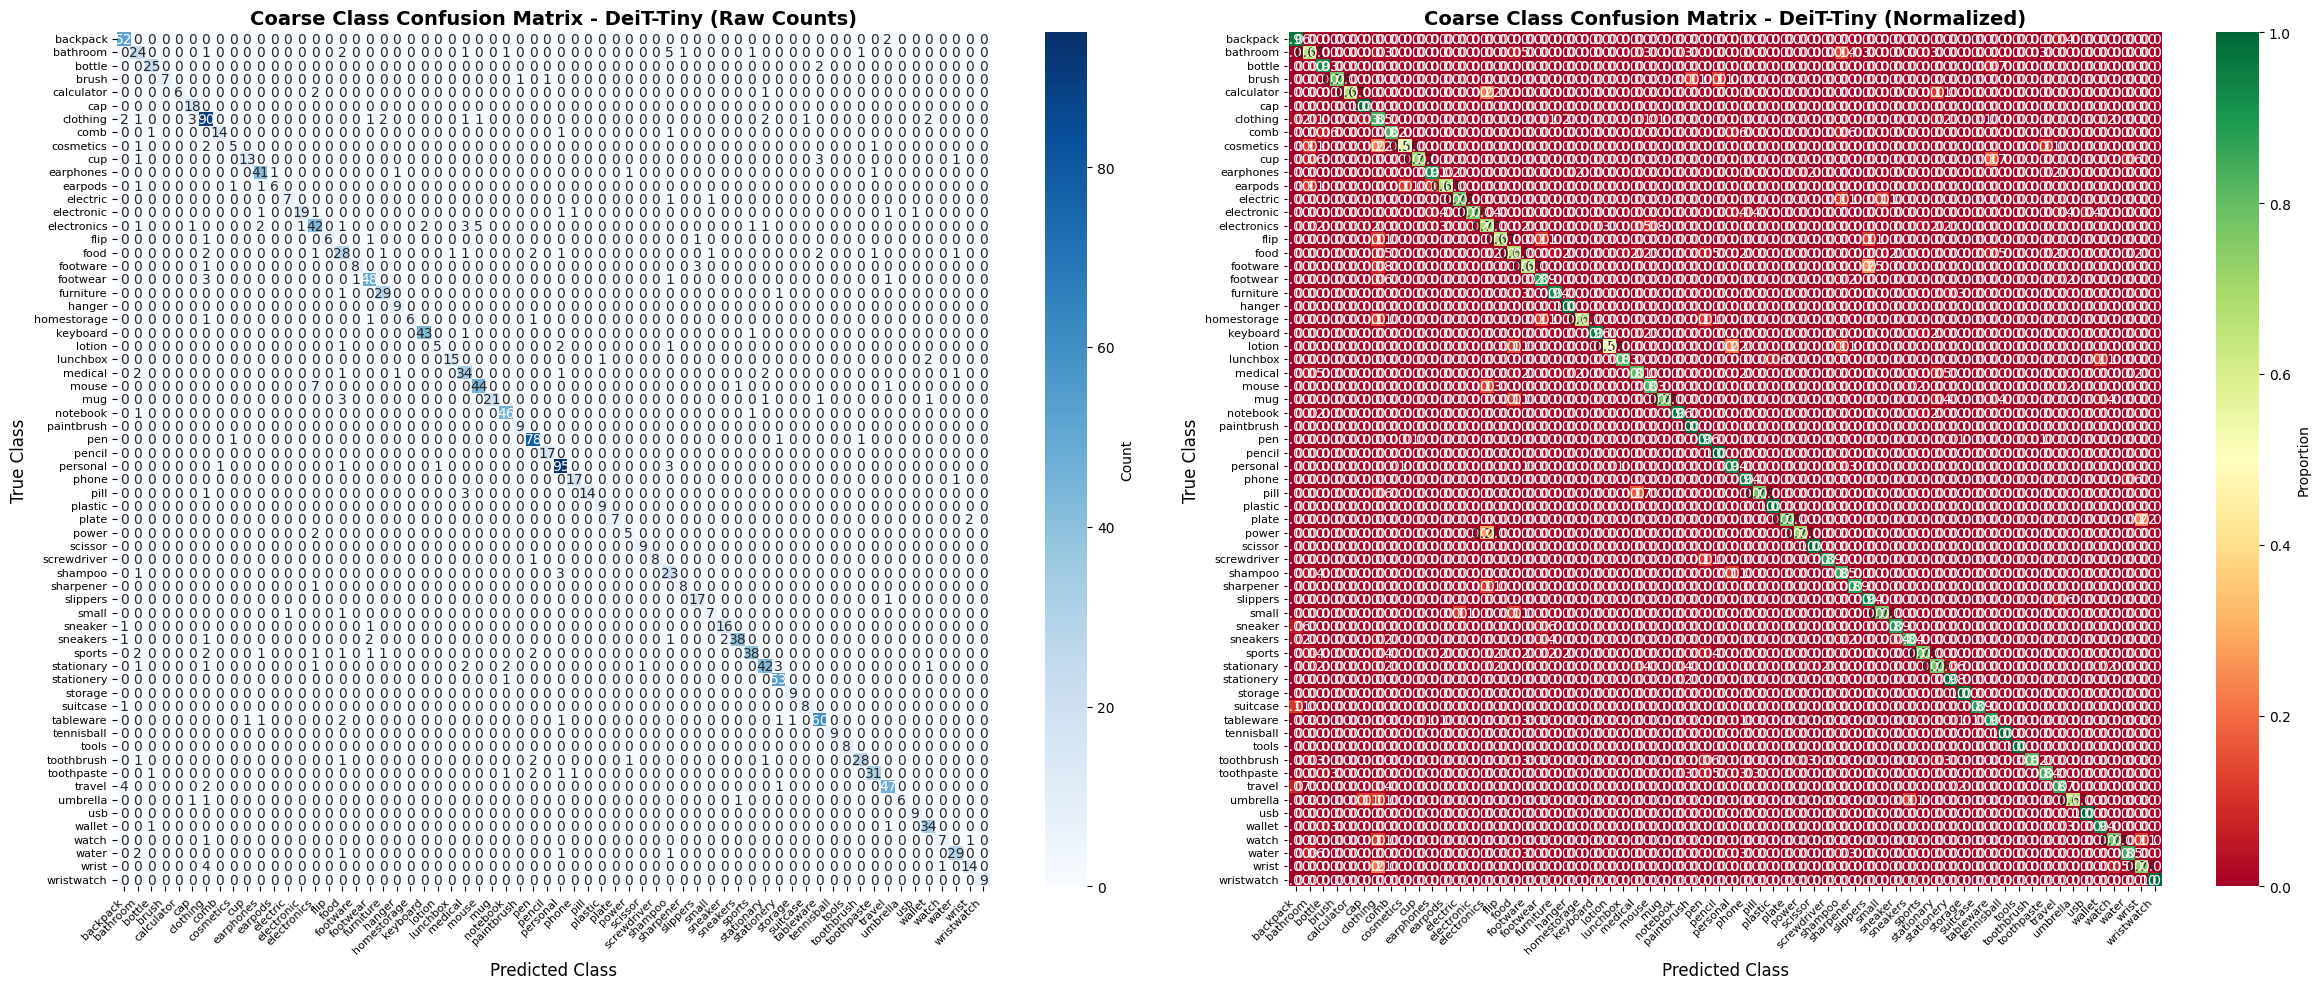

/tmp/ipykernel_34868/287899780.py:76: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


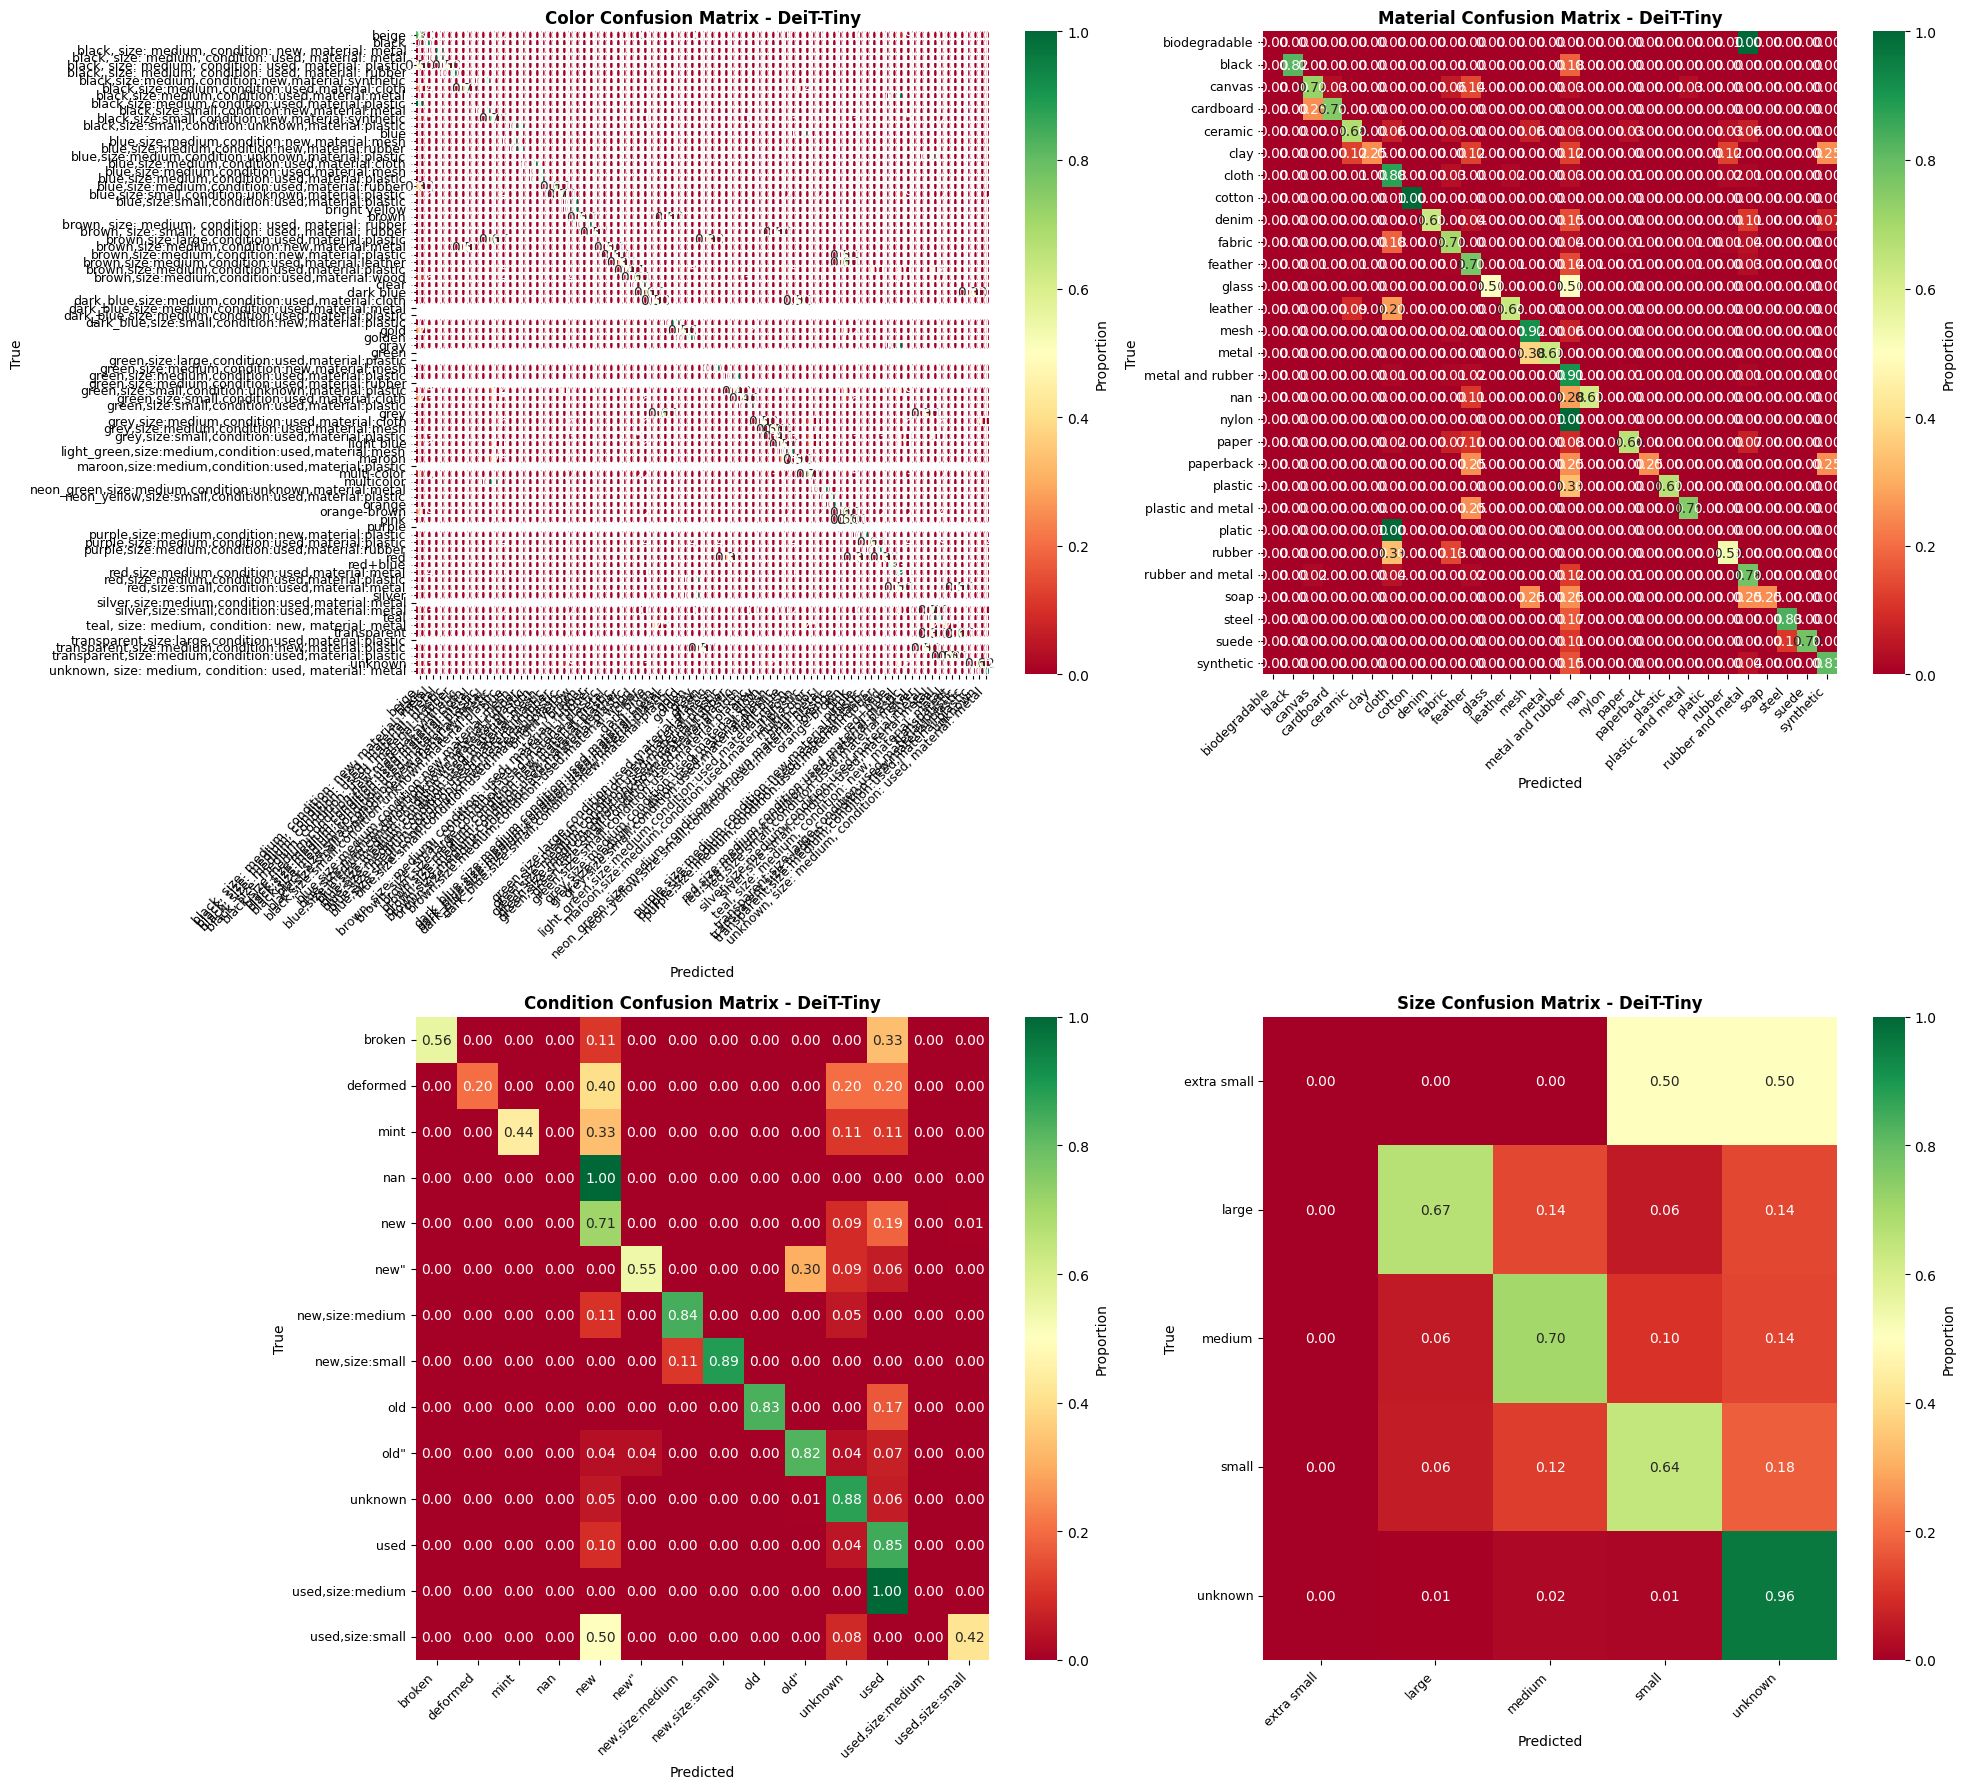

✅ Confusion matrices generated!


In [17]:
# 📊 Confusion Matrices - Detailed Classification Analysis

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating confusion matrices...")

def get_predictions_and_labels(model, loader, facets):
    """Extract predictions and ground truth labels."""
    model.eval()
    all_preds = {facet: [] for facet in facets}
    all_labels = {facet: [] for facet in facets}
    
    with torch.no_grad():
        for images, facet_ids, _, _ in loader:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(images)
            
            for facet in facets:
                preds = logits_attrs[facet].argmax(dim=1).cpu().numpy()
                labels = facet_batch[facet].cpu().numpy()
                all_preds[facet].extend(preds)
                all_labels[facet].extend(labels)
    
    return {facet: np.array(all_preds[facet]) for facet in facets}, \
           {facet: np.array(all_labels[facet]) for facet in facets}

# Get predictions for DeiT model
preds_deit, labels_deit = get_predictions_and_labels(model_unified, test_loader_unified, FACETS_UNIFIED)

# Create confusion matrices for coarse classes
cm_coarse = confusion_matrix(labels_deit['coarse_class'], preds_deit['coarse_class'])
cm_coarse_norm = cm_coarse.astype('float') / cm_coarse.sum(axis=1)[:, np.newaxis]

# Get class names
coarse_class_names = [id_to_facet_value_unified['coarse_class'][i] for i in range(len(cm_coarse))]

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Raw confusion matrix
ax = axes[0]
sns.heatmap(cm_coarse, annot=True, fmt='d', cmap='Blues',
            xticklabels=coarse_class_names, yticklabels=coarse_class_names, ax=ax,
            cbar_kws={'label': 'Count'})
ax.set_title('Coarse Class Confusion Matrix - DeiT-Tiny (Raw Counts)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

# Normalized confusion matrix
ax = axes[1]
sns.heatmap(cm_coarse_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=coarse_class_names, yticklabels=coarse_class_names, ax=ax,
            vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
ax.set_title('Coarse Class Confusion Matrix - DeiT-Tiny (Normalized)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# Confusion matrices for attributes
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.flatten()

for idx, facet in enumerate(['color', 'material', 'condition', 'size']):
    cm = confusion_matrix(labels_deit[facet], preds_deit[facet])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Get attribute names
    attr_names = [id_to_facet_value_unified[facet][i] for i in range(len(cm))]
    
    ax = axes[idx]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=attr_names, yticklabels=attr_names, ax=ax,
                vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
    ax.set_title(f'{facet.capitalize()} Confusion Matrix - DeiT-Tiny', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Confusion matrices generated!")


Creating performance comparison charts...


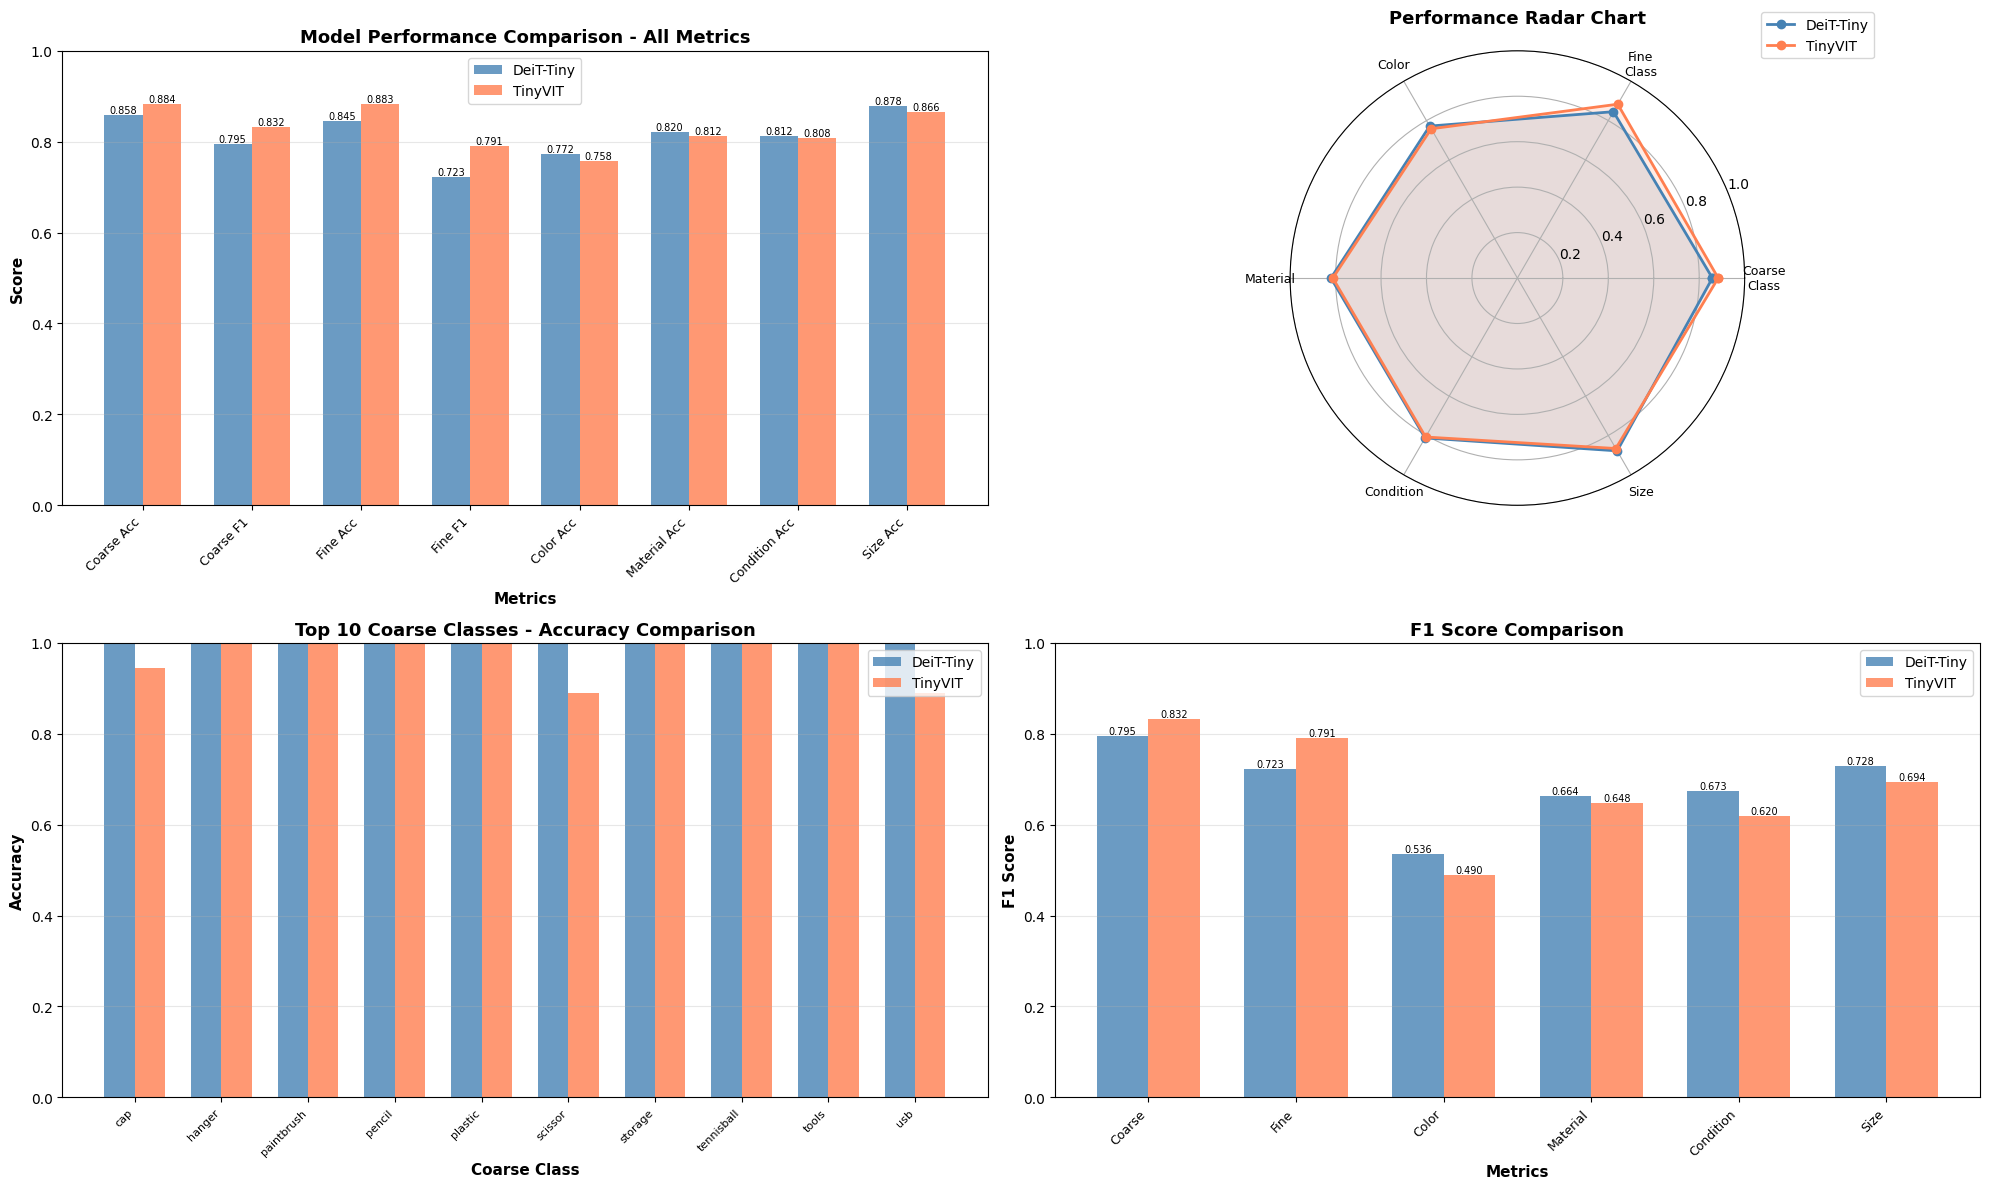

✅ Performance comparison charts generated!


In [18]:
# 📊 Performance Comparison Charts - Visual Model Comparison

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Creating performance comparison charts...")

# Prepare data for visualization
metrics_to_plot = {
    'Coarse Acc': ('coarse_class_acc', test_metrics_unified, test_metrics_tinyvit),
    'Coarse F1': ('coarse_class_f1', test_metrics_unified, test_metrics_tinyvit),
    'Fine Acc': ('fine_class_acc', test_metrics_unified, test_metrics_tinyvit),
    'Fine F1': ('fine_class_f1', test_metrics_unified, test_metrics_tinyvit),
    'Color Acc': ('color_acc', test_metrics_unified, test_metrics_tinyvit),
    'Material Acc': ('material_acc', test_metrics_unified, test_metrics_tinyvit),
    'Condition Acc': ('condition_acc', test_metrics_unified, test_metrics_tinyvit),
    'Size Acc': ('size_acc', test_metrics_unified, test_metrics_tinyvit),
}

# Create figure with multiple subplots
fig = plt.figure(figsize=(20, 12))

# 1. Bar Chart Comparison
ax1 = plt.subplot(2, 2, 1)
metric_names = list(metrics_to_plot.keys())
deit_values = [metrics_to_plot[m][1][metrics_to_plot[m][0]] for m in metric_names]
tinyvit_values = [metrics_to_plot[m][2][metrics_to_plot[m][0]] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax1.bar(x - width/2, deit_values, width, label='DeiT-Tiny', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, tinyvit_values, width, label='TinyVIT', color='coral', alpha=0.8)

ax1.set_xlabel('Metrics', fontsize=11, fontweight='bold')
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Model Performance Comparison - All Metrics', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=45, ha='right', fontsize=9)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7)

# 2. Radar Chart
ax2 = plt.subplot(2, 2, 2, projection='polar')

# Select key metrics for radar
radar_metrics = ['coarse_class_acc', 'fine_class_acc', 'color_acc', 'material_acc', 'condition_acc', 'size_acc']
radar_labels = ['Coarse\nClass', 'Fine\nClass', 'Color', 'Material', 'Condition', 'Size']

deit_radar = [test_metrics_unified[m] for m in radar_metrics]
tinyvit_radar = [test_metrics_tinyvit[m] for m in radar_metrics]

# Number of variables
num_vars = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Complete the circle
deit_radar += deit_radar[:1]
tinyvit_radar += tinyvit_radar[:1]
angles += angles[:1]

ax2.plot(angles, deit_radar, 'o-', linewidth=2, label='DeiT-Tiny', color='steelblue')
ax2.fill(angles, deit_radar, alpha=0.15, color='steelblue')
ax2.plot(angles, tinyvit_radar, 'o-', linewidth=2, label='TinyVIT', color='coral')
ax2.fill(angles, tinyvit_radar, alpha=0.15, color='coral')

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(radar_labels, fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_title('Performance Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax2.grid(True)

# 3. Per-class Accuracy Comparison (Top 10 Coarse Classes)
ax3 = plt.subplot(2, 2, 3)

# Get per-class accuracy for top 10 coarse classes by frequency
top_10_classes = sorted(coarse_acc_deit.keys(), key=lambda x: coarse_acc_deit.get(x, 0), reverse=True)[:10]
class_names_short = [id_to_facet_value_unified['coarse_class'].get(c, f"C{c}")[:15] for c in top_10_classes]
deit_class_acc = [coarse_acc_deit.get(c, 0) for c in top_10_classes]
tiny_class_acc = [coarse_acc_tiny.get(c, 0) for c in top_10_classes]

x = np.arange(len(class_names_short))
width = 0.35

ax3.bar(x - width/2, deit_class_acc, width, label='DeiT-Tiny', color='steelblue', alpha=0.8)
ax3.bar(x + width/2, tiny_class_acc, width, label='TinyVIT', color='coral', alpha=0.8)

ax3.set_xlabel('Coarse Class', fontsize=11, fontweight='bold')
ax3.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax3.set_title('Top 10 Coarse Classes - Accuracy Comparison', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(class_names_short, rotation=45, ha='right', fontsize=8)
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0, 1])

# 4. F1 Score Comparison
ax4 = plt.subplot(2, 2, 4)

f1_metrics = {
    'Coarse': ('coarse_class_f1', test_metrics_unified, test_metrics_tinyvit),
    'Fine': ('fine_class_f1', test_metrics_unified, test_metrics_tinyvit),
    'Color': ('color_f1', test_metrics_unified, test_metrics_tinyvit),
    'Material': ('material_f1', test_metrics_unified, test_metrics_tinyvit),
    'Condition': ('condition_f1', test_metrics_unified, test_metrics_tinyvit),
    'Size': ('size_f1', test_metrics_unified, test_metrics_tinyvit),
}

f1_names = list(f1_metrics.keys())
deit_f1_values = [f1_metrics[m][1][f1_metrics[m][0]] for m in f1_names]
tinyvit_f1_values = [f1_metrics[m][2][f1_metrics[m][0]] for m in f1_names]

x = np.arange(len(f1_names))
width = 0.35

bars1 = ax4.bar(x - width/2, deit_f1_values, width, label='DeiT-Tiny', color='steelblue', alpha=0.8)
bars2 = ax4.bar(x + width/2, tinyvit_f1_values, width, label='TinyVIT', color='coral', alpha=0.8)

ax4.set_xlabel('Metrics', fontsize=11, fontweight='bold')
ax4.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax4.set_title('F1 Score Comparison', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(f1_names, rotation=45, ha='right', fontsize=9)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print("✅ Performance comparison charts generated!")


Analyzing confidence scores...


/tmp/ipykernel_34868/348854277.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


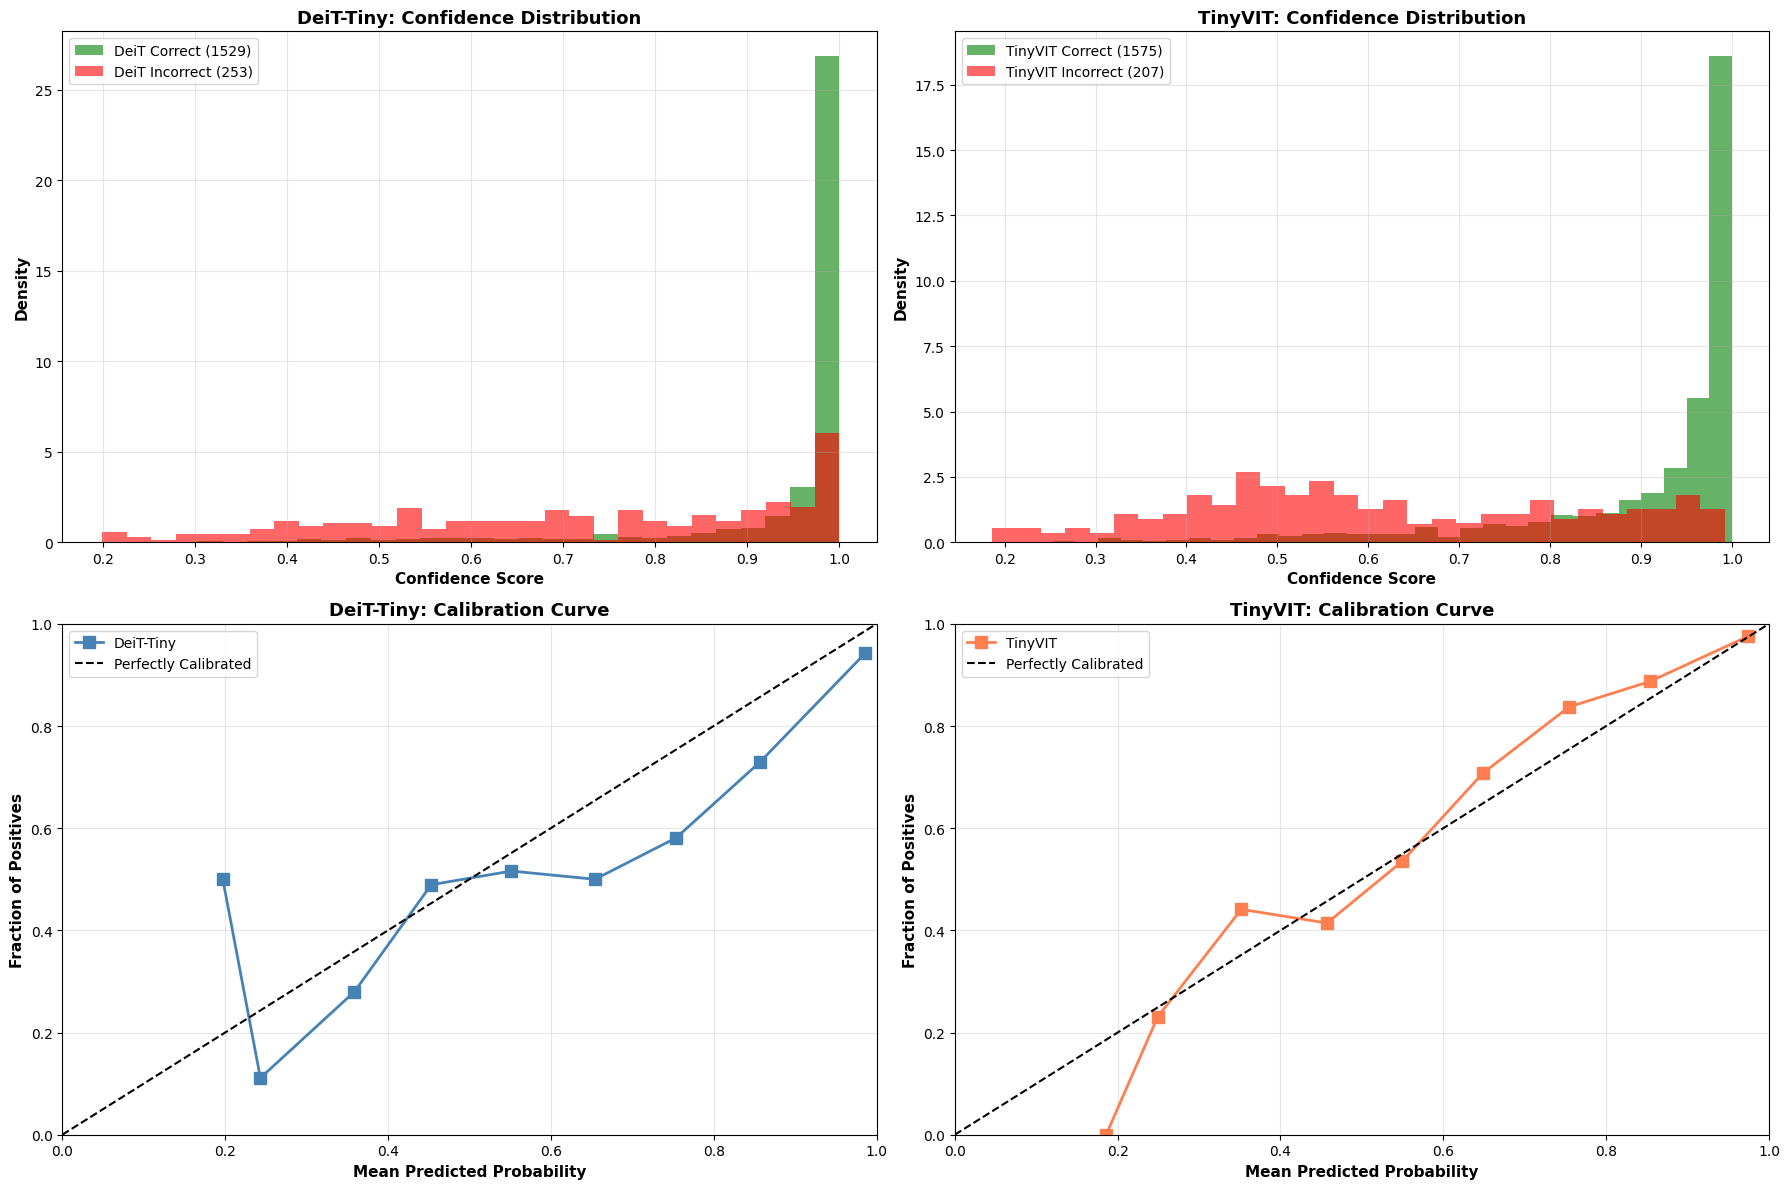


CONFIDENCE SCORE STATISTICS

DeiT-Tiny:
  Mean confidence (correct): 0.9463
  Mean confidence (incorrect): 0.7183
  Confidence gap: 0.2280

TinyVIT:
  Mean confidence (correct): 0.9053
  Mean confidence (incorrect): 0.6147
  Confidence gap: 0.2905

✅ Confidence analysis complete!


In [19]:
# 📊 Confidence Score Analysis - Model Reliability Assessment

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

print("Analyzing confidence scores...")

def get_confidence_scores(model, loader):
    """Extract confidence scores and correctness for coarse class predictions."""
    model.eval()
    confidences = []
    correct_flags = []
    
    with torch.no_grad():
        for images, facet_ids, _, _ in loader:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(images)
            
            probs = F.softmax(logits_attrs['coarse_class'], dim=1)
            max_probs, preds = torch.max(probs, dim=1)
            
            confidences.extend(max_probs.cpu().numpy())
            correct = (preds == facet_batch['coarse_class']).cpu().numpy()
            correct_flags.extend(correct)
    
    return np.array(confidences), np.array(correct_flags)

# Get confidence scores
conf_deit, correct_deit = get_confidence_scores(model_unified, test_loader_unified)
conf_tiny, correct_tiny = get_confidence_scores(model_unified_tinyvit, test_loader_unified)

# Split into correct and incorrect predictions
conf_correct_deit = conf_deit[correct_deit]
conf_incorrect_deit = conf_deit[~correct_deit]
conf_correct_tiny = conf_tiny[correct_tiny]
conf_incorrect_tiny = conf_tiny[~correct_tiny]

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Confidence Distribution - DeiT
ax = axes[0, 0]
ax.hist(conf_correct_deit, bins=30, alpha=0.6, label=f'DeiT Correct ({len(conf_correct_deit)})',
        color='green', density=True)
ax.hist(conf_incorrect_deit, bins=30, alpha=0.6, label=f'DeiT Incorrect ({len(conf_incorrect_deit)})',
        color='red', density=True)
ax.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('DeiT-Tiny: Confidence Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2. Confidence Distribution - TinyVIT
ax = axes[0, 1]
ax.hist(conf_correct_tiny, bins=30, alpha=0.6, label=f'TinyVIT Correct ({len(conf_correct_tiny)})',
        color='green', density=True)
ax.hist(conf_incorrect_tiny, bins=30, alpha=0.6, label=f'TinyVIT Incorrect ({len(conf_incorrect_tiny)})',
        color='red', density=True)
ax.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('TinyVIT: Confidence Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 3. Calibration Curve - DeiT
ax = axes[1, 0]
fraction_of_positives_deit, mean_predicted_value_deit = calibration_curve(
    correct_deit, conf_deit, n_bins=10, strategy='uniform'
)
ax.plot(mean_predicted_value_deit, fraction_of_positives_deit, 's-', 
        label='DeiT-Tiny', color='steelblue', linewidth=2, markersize=8)
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=1.5)
ax.set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
ax.set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
ax.set_title('DeiT-Tiny: Calibration Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# 4. Calibration Curve - TinyVIT
ax = axes[1, 1]
fraction_of_positives_tiny, mean_predicted_value_tiny = calibration_curve(
    correct_tiny, conf_tiny, n_bins=10, strategy='uniform'
)
ax.plot(mean_predicted_value_tiny, fraction_of_positives_tiny, 's-', 
        label='TinyVIT', color='coral', linewidth=2, markersize=8)
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=1.5)
ax.set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
ax.set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
ax.set_title('TinyVIT: Calibration Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("CONFIDENCE SCORE STATISTICS")
print("="*80)
print(f"\nDeiT-Tiny:")
print(f"  Mean confidence (correct): {conf_correct_deit.mean():.4f}")
print(f"  Mean confidence (incorrect): {conf_incorrect_deit.mean():.4f}")
print(f"  Confidence gap: {conf_correct_deit.mean() - conf_incorrect_deit.mean():.4f}")

print(f"\nTinyVIT:")
print(f"  Mean confidence (correct): {conf_correct_tiny.mean():.4f}")
print(f"  Mean confidence (incorrect): {conf_incorrect_tiny.mean():.4f}")
print(f"  Confidence gap: {conf_correct_tiny.mean() - conf_incorrect_tiny.mean():.4f}")

print("\n✅ Confidence analysis complete!")


Creating sample predictions grid...


/tmp/ipykernel_34868/3393523486.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


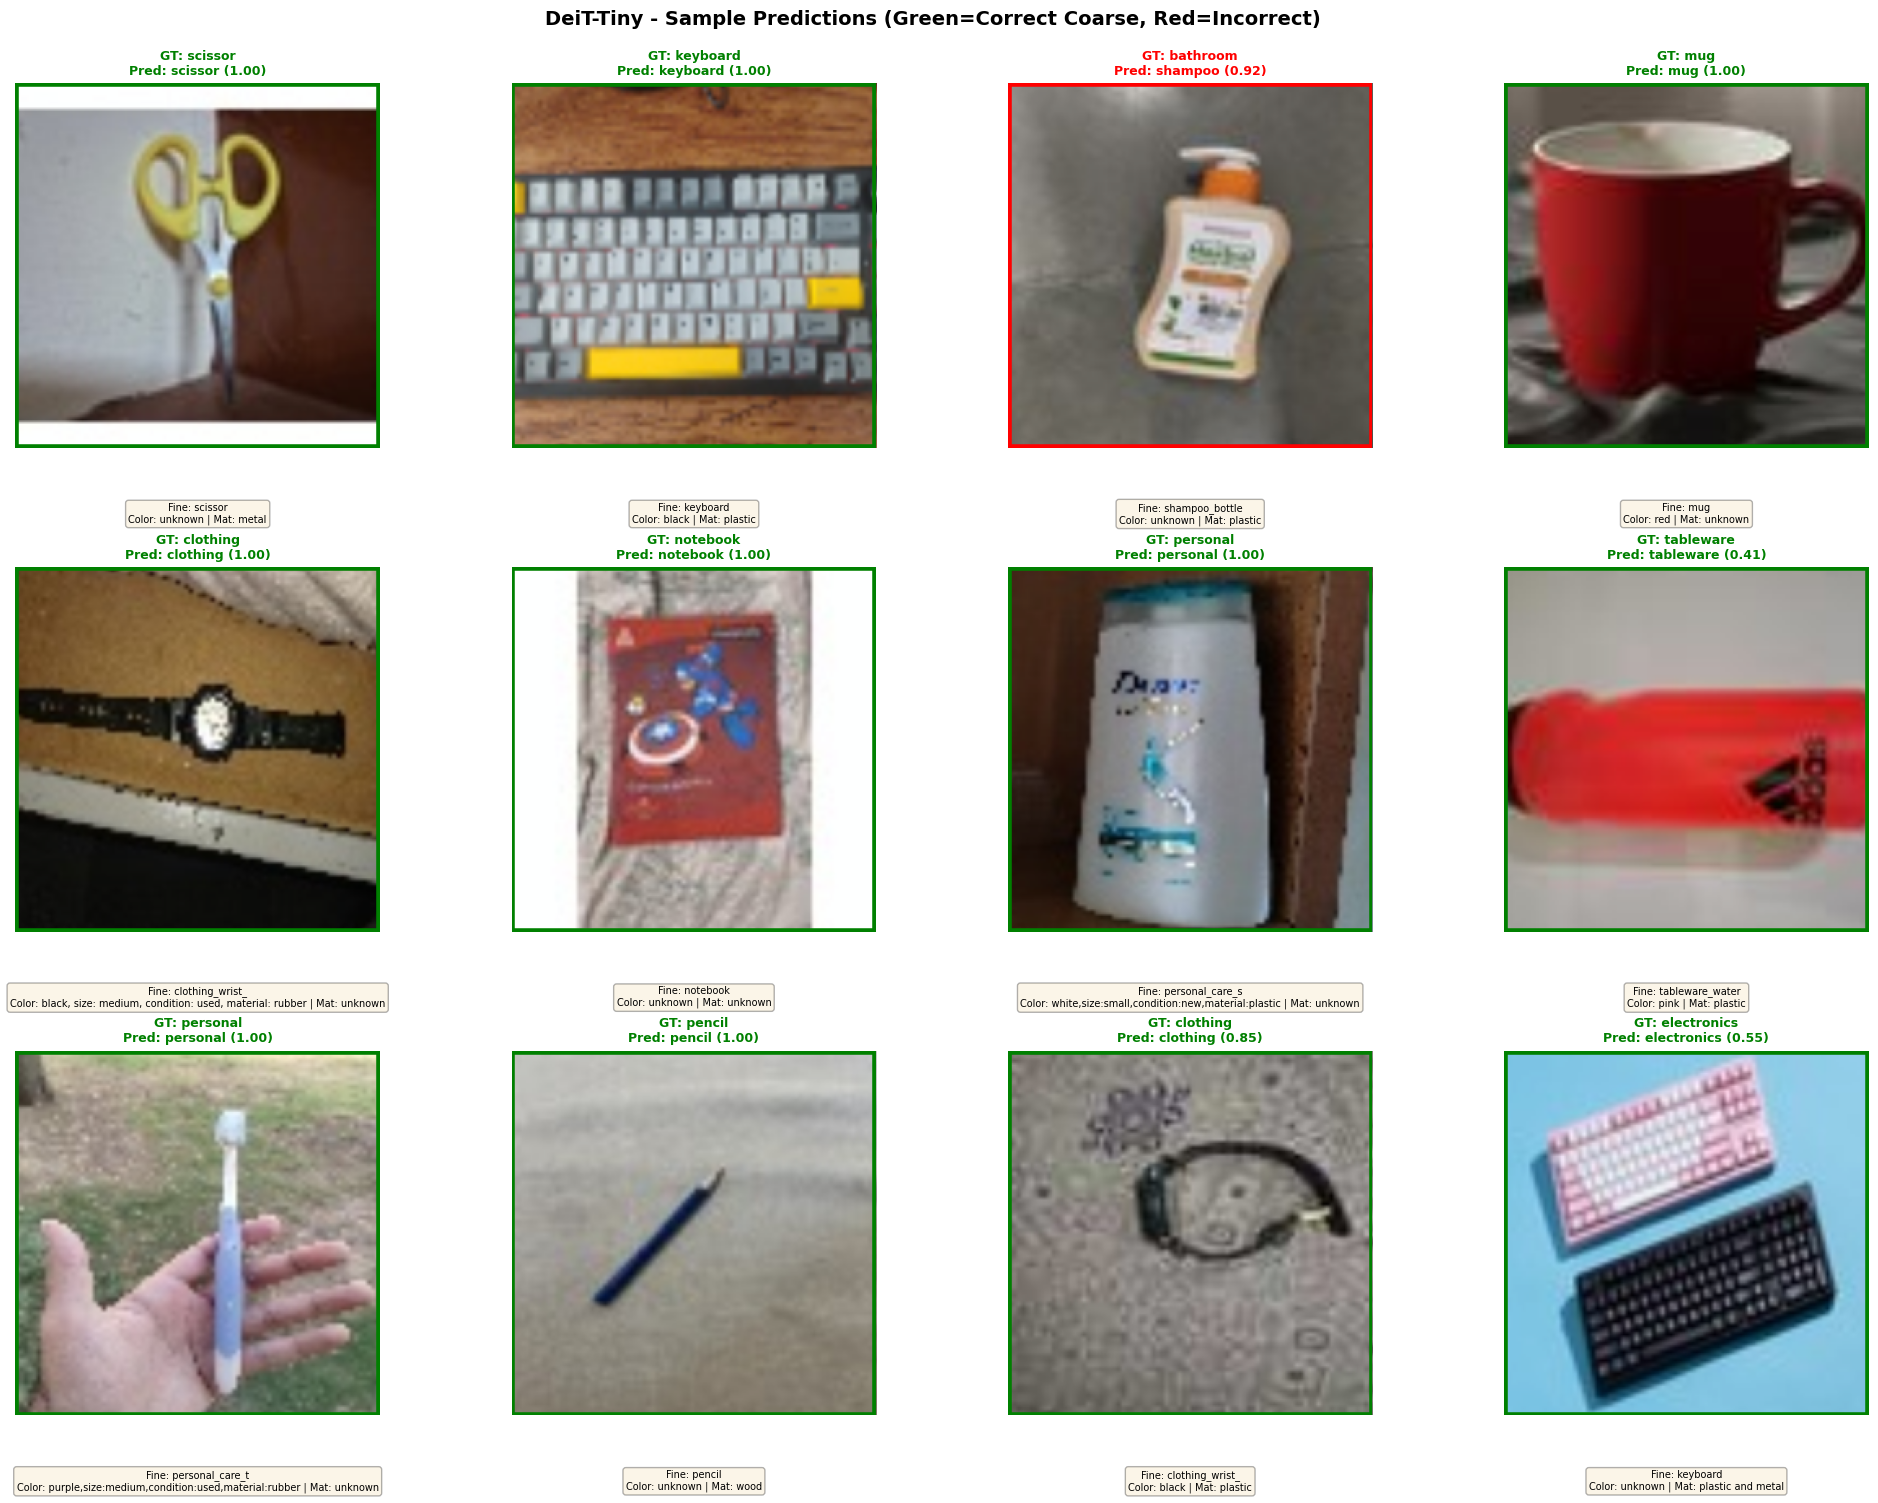

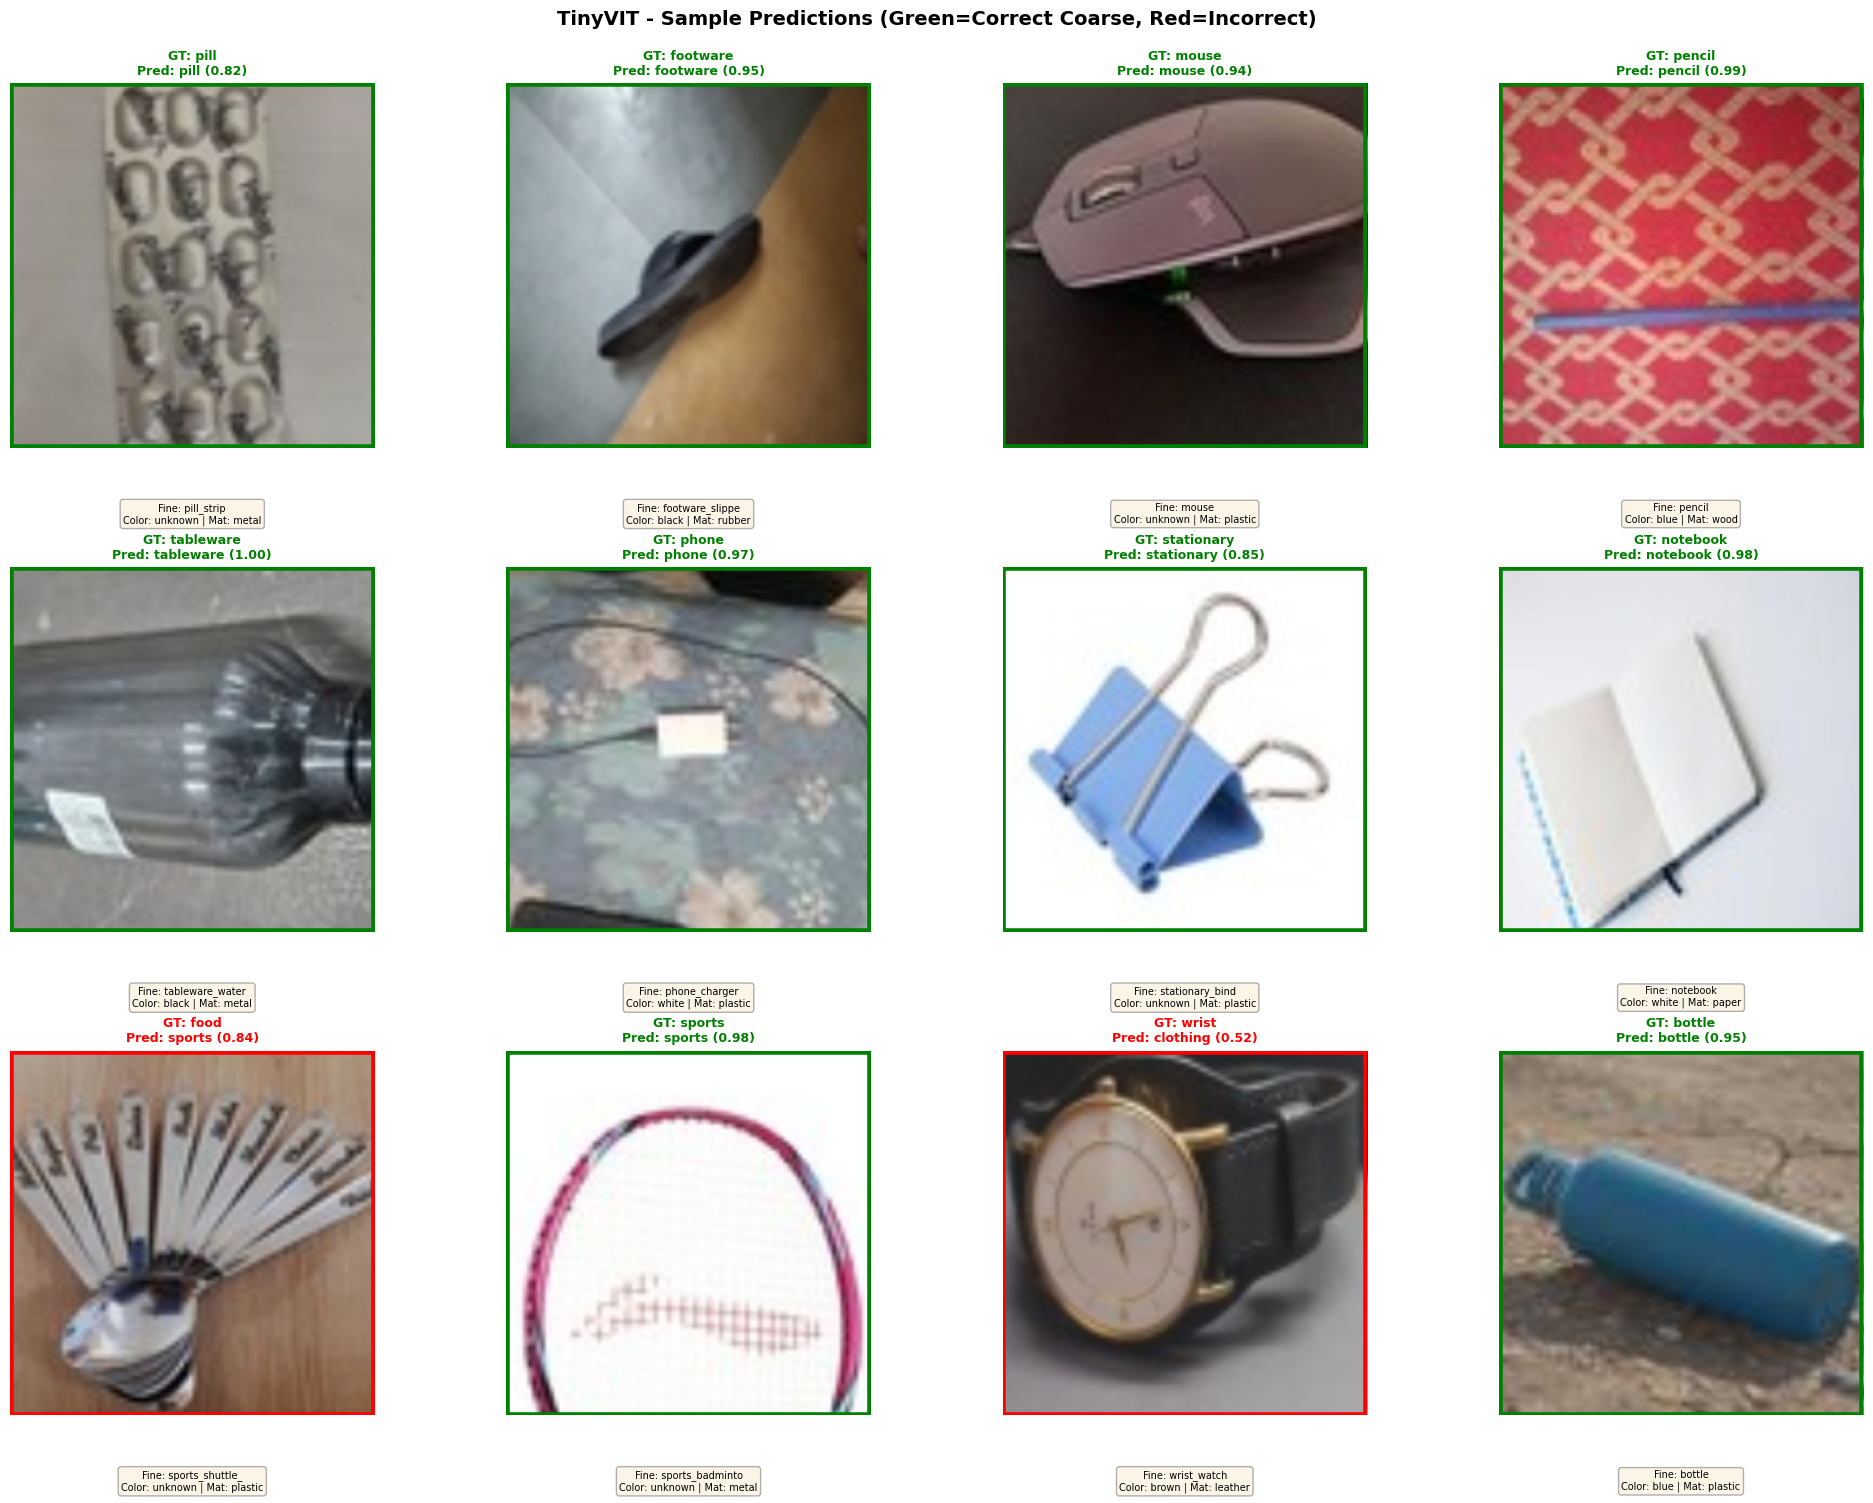

✅ Sample prediction grids generated!


In [20]:
# 📊 Sample Predictions Grid - Visual Examples

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

print("Creating sample predictions grid...")

def visualize_predictions(model, dataset, num_samples=12, model_name="Model"):
    """Visualize sample predictions with images."""
    model.eval()
    
    # Randomly sample indices
    indices = random.sample(range(len(dataset)), num_samples)
    
    # Create figure
    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
    axes = axes.flatten()
    
    for idx, sample_idx in enumerate(indices):
        image, facet_ids, caption, img_path = dataset[sample_idx]
        
        # Get ground truth
        gt_coarse = id_to_facet_value_unified['coarse_class'][facet_ids['coarse_class']]
        gt_fine = id_to_facet_value_unified['fine_class'][facet_ids['fine_class']]
        gt_color = id_to_facet_value_unified['color'][facet_ids['color']]
        gt_material = id_to_facet_value_unified['material'][facet_ids['material']]
        
        # Get predictions
        img_tensor = image.unsqueeze(0).to(device)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(img_tensor)
        
        # Predicted values
        pred_coarse_id = logits_attrs['coarse_class'].argmax(dim=1).item()
        pred_fine_id = logits_attrs['fine_class'].argmax(dim=1).item()
        pred_color_id = logits_attrs['color'].argmax(dim=1).item()
        pred_material_id = logits_attrs['material'].argmax(dim=1).item()
        
        pred_coarse = id_to_facet_value_unified['coarse_class'][pred_coarse_id]
        pred_fine = id_to_facet_value_unified['fine_class'][pred_fine_id]
        pred_color = id_to_facet_value_unified['color'][pred_color_id]
        pred_material = id_to_facet_value_unified['material'][pred_material_id]
        
        # Get confidence scores
        conf_coarse = F.softmax(logits_attrs['coarse_class'], dim=1)[0, pred_coarse_id].item()
        conf_fine = F.softmax(logits_attrs['fine_class'], dim=1)[0, pred_fine_id].item()
        
        # Check correctness
        coarse_correct = (pred_coarse_id == facet_ids['coarse_class'])
        fine_correct = (pred_fine_id == facet_ids['fine_class'])
        
        # Denormalize and display image
        ax = axes[idx]
        img_display = image.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = img_display * std + mean
        img_display = np.clip(img_display, 0, 1)
        
        ax.imshow(img_display)
        ax.axis('off')
        
        # Add border color based on correctness
        border_color = 'green' if coarse_correct else 'red'
        border_width = 4
        rect = Rectangle((0, 0), img_display.shape[1]-1, img_display.shape[0]-1,
                        linewidth=border_width, edgecolor=border_color, facecolor='none')
        ax.add_patch(rect)
        
        # Add text with predictions
        title = f"GT: {gt_coarse[:12]}\nPred: {pred_coarse[:12]} ({conf_coarse:.2f})"
        title_color = 'green' if coarse_correct else 'red'
        ax.set_title(title, fontsize=9, fontweight='bold', color=title_color)
        
        # Add detailed info at the bottom
        info_text = f"Fine: {pred_fine[:15]}\nColor: {pred_color} | Mat: {pred_material}"
        ax.text(0.5, -0.15, info_text, transform=ax.transAxes,
               fontsize=7, ha='center', va='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle(f'{model_name} - Sample Predictions (Green=Correct Coarse, Red=Incorrect)',
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Visualize predictions from both models
visualize_predictions(model_unified, test_set_unified, num_samples=12, model_name="DeiT-Tiny")
visualize_predictions(model_unified_tinyvit, test_set_unified, num_samples=12, model_name="TinyVIT")

print("✅ Sample prediction grids generated!")


Analyzing misclassification patterns...


/tmp/ipykernel_34868/4246389819.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):


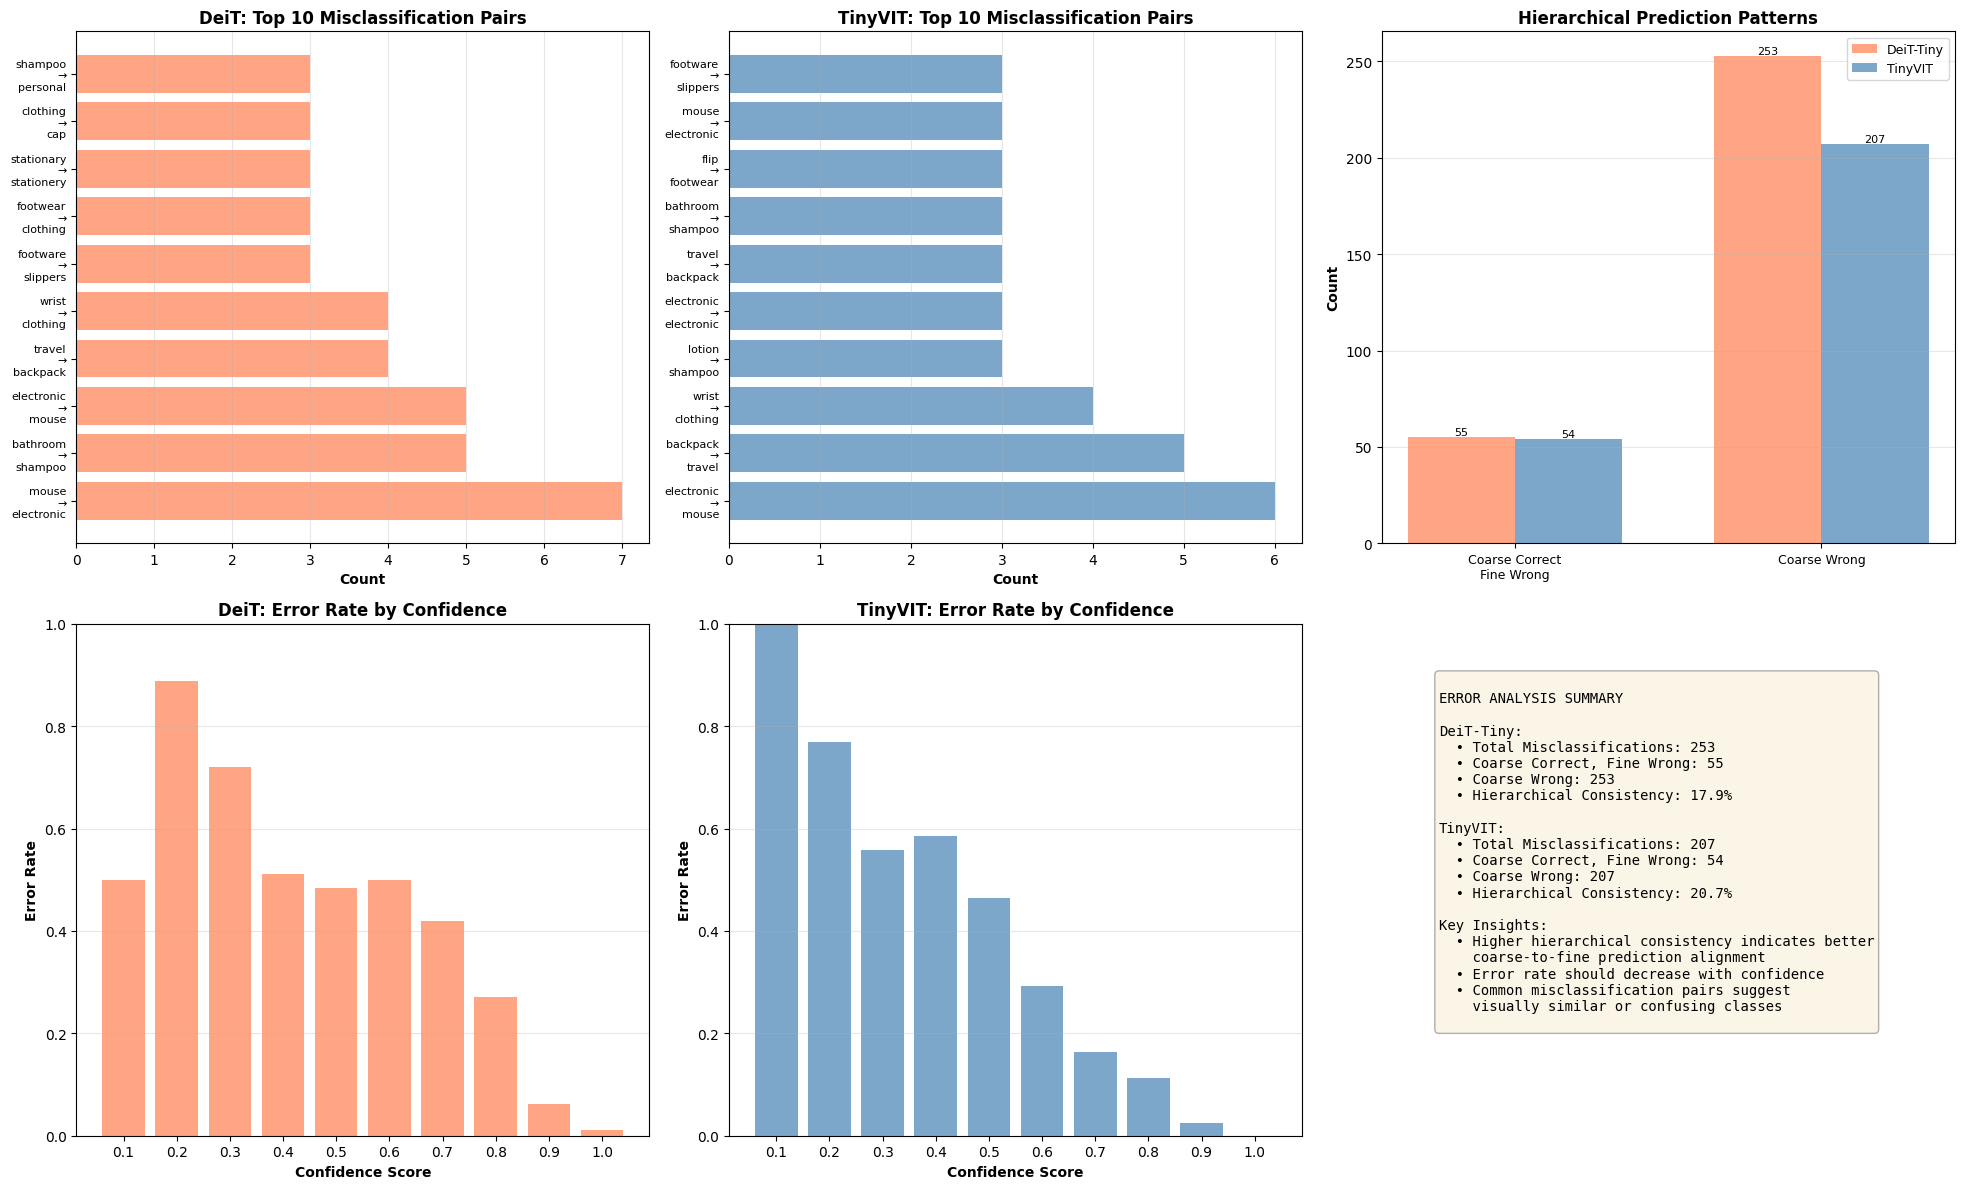

✅ Error analysis complete!


In [21]:
# 📊 Error Analysis & Misclassification Patterns

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

print("Analyzing misclassification patterns...")

def analyze_misclassifications(model, loader, model_name="Model"):
    """Analyze common misclassification patterns."""
    model.eval()
    
    # Track misclassifications
    misclass_pairs = []  # (true_class, pred_class) pairs
    hierarchical_errors = {'coarse_correct_fine_wrong': 0, 'coarse_wrong': 0}
    confidence_errors = defaultdict(list)  # confidence -> is_correct
    
    with torch.no_grad():
        for images, facet_ids, _, _ in loader:
            images = images.to(device, non_blocking=True)
            facet_batch = {f: torch.as_tensor([d[f] for d in facet_ids], device=device) for f in FACETS_UNIFIED}
            
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                _, logits_attrs, _ = model(images)
            
            # Get predictions
            pred_coarse = logits_attrs['coarse_class'].argmax(dim=1)
            pred_fine = logits_attrs['fine_class'].argmax(dim=1)
            
            true_coarse = facet_batch['coarse_class']
            true_fine = facet_batch['fine_class']
            
            # Get confidence scores
            probs_coarse = F.softmax(logits_attrs['coarse_class'], dim=1)
            conf_scores = probs_coarse.max(dim=1)[0].cpu().numpy()
            
            # Analyze each prediction
            for i in range(len(images)):
                coarse_correct = (pred_coarse[i] == true_coarse[i]).item()
                fine_correct = (pred_fine[i] == true_fine[i]).item()
                
                # Track hierarchical errors
                if coarse_correct and not fine_correct:
                    hierarchical_errors['coarse_correct_fine_wrong'] += 1
                elif not coarse_correct:
                    hierarchical_errors['coarse_wrong'] += 1
                    # Track misclassification pairs
                    true_class = true_coarse[i].item()
                    pred_class = pred_coarse[i].item()
                    misclass_pairs.append((true_class, pred_class))
                
                # Track confidence vs correctness
                conf_bucket = int(conf_scores[i] * 10) / 10  # Round to nearest 0.1
                confidence_errors[conf_bucket].append(coarse_correct)
    
    return misclass_pairs, hierarchical_errors, confidence_errors

# Analyze both models
misclass_deit, hier_deit, conf_errors_deit = analyze_misclassifications(
    model_unified, test_loader_unified, "DeiT-Tiny"
)
misclass_tiny, hier_tiny, conf_errors_tiny = analyze_misclassifications(
    model_unified_tinyvit, test_loader_unified, "TinyVIT"
)

# Create visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Most Common Misclassification Pairs - DeiT
ax1 = plt.subplot(2, 3, 1)
most_common_deit = Counter(misclass_deit).most_common(10)
if most_common_deit:
    labels = [f"{id_to_facet_value_unified['coarse_class'][true][:10]}\n→\n{id_to_facet_value_unified['coarse_class'][pred][:10]}" 
              for (true, pred), _ in most_common_deit]
    counts = [count for _, count in most_common_deit]
    
    ax1.barh(range(len(labels)), counts, color='coral', alpha=0.7)
    ax1.set_yticks(range(len(labels)))
    ax1.set_yticklabels(labels, fontsize=8)
    ax1.set_xlabel('Count', fontsize=10, fontweight='bold')
    ax1.set_title('DeiT: Top 10 Misclassification Pairs', fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

# 2. Most Common Misclassification Pairs - TinyVIT
ax2 = plt.subplot(2, 3, 2)
most_common_tiny = Counter(misclass_tiny).most_common(10)
if most_common_tiny:
    labels = [f"{id_to_facet_value_unified['coarse_class'][true][:10]}\n→\n{id_to_facet_value_unified['coarse_class'][pred][:10]}" 
              for (true, pred), _ in most_common_tiny]
    counts = [count for _, count in most_common_tiny]
    
    ax2.barh(range(len(labels)), counts, color='steelblue', alpha=0.7)
    ax2.set_yticks(range(len(labels)))
    ax2.set_yticklabels(labels, fontsize=8)
    ax2.set_xlabel('Count', fontsize=10, fontweight='bold')
    ax2.set_title('TinyVIT: Top 10 Misclassification Pairs', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)

# 3. Hierarchical Consistency Analysis
ax3 = plt.subplot(2, 3, 3)
categories = ['Coarse Correct\nFine Wrong', 'Coarse Wrong']
deit_values = [hier_deit['coarse_correct_fine_wrong'], hier_deit['coarse_wrong']]
tiny_values = [hier_tiny['coarse_correct_fine_wrong'], hier_tiny['coarse_wrong']]

x = np.arange(len(categories))
width = 0.35

ax3.bar(x - width/2, deit_values, width, label='DeiT-Tiny', color='coral', alpha=0.7)
ax3.bar(x + width/2, tiny_values, width, label='TinyVIT', color='steelblue', alpha=0.7)

ax3.set_ylabel('Count', fontsize=10, fontweight='bold')
ax3.set_title('Hierarchical Prediction Patterns', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(categories, fontsize=9)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, (d_val, t_val) in enumerate(zip(deit_values, tiny_values)):
    ax3.text(i - width/2, d_val, str(d_val), ha='center', va='bottom', fontsize=8)
    ax3.text(i + width/2, t_val, str(t_val), ha='center', va='bottom', fontsize=8)

# 4. Error Rate by Confidence - DeiT
ax4 = plt.subplot(2, 3, 4)
conf_buckets_deit = sorted(conf_errors_deit.keys())
error_rates_deit = [1 - np.mean(conf_errors_deit[bucket]) for bucket in conf_buckets_deit if len(conf_errors_deit[bucket]) > 0]
counts_deit = [len(conf_errors_deit[bucket]) for bucket in conf_buckets_deit if len(conf_errors_deit[bucket]) > 0]

if error_rates_deit:
    ax4.bar([f"{b:.1f}" for b in conf_buckets_deit if len(conf_errors_deit[b]) > 0], 
            error_rates_deit, color='coral', alpha=0.7)
    ax4.set_xlabel('Confidence Score', fontsize=10, fontweight='bold')
    ax4.set_ylabel('Error Rate', fontsize=10, fontweight='bold')
    ax4.set_title('DeiT: Error Rate by Confidence', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim([0, 1])

# 5. Error Rate by Confidence - TinyVIT
ax5 = plt.subplot(2, 3, 5)
conf_buckets_tiny = sorted(conf_errors_tiny.keys())
error_rates_tiny = [1 - np.mean(conf_errors_tiny[bucket]) for bucket in conf_buckets_tiny if len(conf_errors_tiny[bucket]) > 0]
counts_tiny = [len(conf_errors_tiny[bucket]) for bucket in conf_buckets_tiny if len(conf_errors_tiny[bucket]) > 0]

if error_rates_tiny:
    ax5.bar([f"{b:.1f}" for b in conf_buckets_tiny if len(conf_errors_tiny[b]) > 0], 
            error_rates_tiny, color='steelblue', alpha=0.7)
    ax5.set_xlabel('Confidence Score', fontsize=10, fontweight='bold')
    ax5.set_ylabel('Error Rate', fontsize=10, fontweight='bold')
    ax5.set_title('TinyVIT: Error Rate by Confidence', fontsize=12, fontweight='bold')
    ax5.grid(axis='y', alpha=0.3)
    ax5.set_ylim([0, 1])

# 6. Summary Statistics
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

summary_text = f"""
ERROR ANALYSIS SUMMARY

DeiT-Tiny:
  • Total Misclassifications: {len(misclass_deit)}
  • Coarse Correct, Fine Wrong: {hier_deit['coarse_correct_fine_wrong']}
  • Coarse Wrong: {hier_deit['coarse_wrong']}
  • Hierarchical Consistency: {hier_deit['coarse_correct_fine_wrong']/(hier_deit['coarse_correct_fine_wrong']+hier_deit['coarse_wrong'])*100:.1f}%

TinyVIT:
  • Total Misclassifications: {len(misclass_tiny)}
  • Coarse Correct, Fine Wrong: {hier_tiny['coarse_correct_fine_wrong']}
  • Coarse Wrong: {hier_tiny['coarse_wrong']}
  • Hierarchical Consistency: {hier_tiny['coarse_correct_fine_wrong']/(hier_tiny['coarse_correct_fine_wrong']+hier_tiny['coarse_wrong'])*100:.1f}%

Key Insights:
  • Higher hierarchical consistency indicates better
    coarse-to-fine prediction alignment
  • Error rate should decrease with confidence
  • Common misclassification pairs suggest
    visually similar or confusing classes
"""

ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("✅ Error analysis complete!")


In [22]:
# Unified classifier that accepts path, PIL.Image, or numpy array
import tempfile
import numpy as np
from PIL import Image

def _ensure_image_path(image_input) -> str:
    # Returns a temp file path if input is PIL/numpy; or the original string if it's already a path
    if isinstance(image_input, str):
        return image_input
    if isinstance(image_input, Image.Image):
        tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.jpg')
        image_input.save(tmp.name)
        return tmp.name
    if isinstance(image_input, np.ndarray):
        img = Image.fromarray(image_input.astype(np.uint8))
        tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.jpg')
        img.save(tmp.name)
        return tmp.name
    raise ValueError("Unsupported image input type; provide str path, PIL.Image, or numpy array.")

@torch.no_grad()
def classify_image_unified(image_path, model: nn.Module, show_image: bool = True, use_hierarchy: bool = True) -> Dict:
    """
    Classify image using unified model (classes as attributes).
    Accepts a file path, PIL.Image, or numpy array.
    """
    actual_path = _ensure_image_path(image_path)
    if not os.path.exists(actual_path):
        raise FileNotFoundError(f"Image not found: {actual_path}")

    # Load and transform image
    img = Image.open(actual_path).convert("RGB")
    img_tensor = val_transforms(img).unsqueeze(0).to(device)

    # Get predictions
    model.eval()
    with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
        feats, logits_attrs, img_emb = model(img_tensor)

    # First, predict coarse class
    coarse_logits = logits_attrs["coarse_class"]
    coarse_pred_id = coarse_logits.argmax(dim=1).item()
    coarse_pred_value = id_to_facet_value_unified["coarse_class"][coarse_pred_id]
    coarse_confidence = torch.softmax(coarse_logits, dim=1)[0, coarse_pred_id].item()

    # Predict fine class with hierarchical constraint
    fine_logits = logits_attrs["fine_class"]
    fine_probs = torch.softmax(fine_logits, dim=1)[0]

    if use_hierarchy and coarse_pred_value in coarse_to_fine_mapping:
        valid_fine_classes = coarse_to_fine_mapping[coarse_pred_value]
        valid_fine_ids = [facet_to_id_unified["fine_class"][fc] for fc in valid_fine_classes]
        masked_probs = torch.zeros_like(fine_probs)
        masked_probs[valid_fine_ids] = fine_probs[valid_fine_ids]
        if masked_probs.sum() > 0:
            masked_probs = masked_probs / masked_probs.sum()
        fine_pred_id = masked_probs.argmax().item()
        fine_confidence = masked_probs[fine_pred_id].item()
    else:
        fine_pred_id = fine_probs.argmax().item()
        fine_confidence = fine_probs[fine_pred_id].item()

    fine_pred_value = id_to_facet_value_unified["fine_class"][fine_pred_id]

    # Decode other attributes
    all_predictions = {
        "coarse_class": {"value": coarse_pred_value, "confidence": coarse_confidence},
        "fine_class": {"value": fine_pred_value, "confidence": fine_confidence}
    }
    for facet in ["color", "material", "condition", "size"]:
        pred_id = logits_attrs[facet].argmax(dim=1).item()
        pred_value = id_to_facet_value_unified[facet][pred_id]
        confidence = torch.softmax(logits_attrs[facet], dim=1)[0, pred_id].item()
        all_predictions[facet] = {"value": pred_value, "confidence": confidence}

    if show_image:
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.axis('off')
            title = f"Coarse: {all_predictions['coarse_class']['value']} | Fine: {all_predictions['fine_class']['value']}"
            plt.title(title)
            plt.tight_layout()
            plt.show()
        except ImportError:
            pass

    return {
        "image_path": actual_path,
        "coarse_class": all_predictions["coarse_class"],
        "fine_class": all_predictions["fine_class"],
        "attributes": {
            "color": all_predictions["color"],
            "material": all_predictions["material"],
            "condition": all_predictions["condition"],
            "size": all_predictions["size"]
        },
        "embedding": img_emb.cpu().numpy()[0]
    }


In [23]:
# Guarded optimizer/scaler for legacy multi-head path (safe if undefined)
if 'model' in globals():
    optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
    frozen = False
else:
    optimizer = None
    scaler = None
    frozen = False

def set_backbone_trainable(module: nn.Module, trainable: bool):
    for p in module.parameters():
        p.requires_grad = trainable


In [24]:
# Prediction function for unified model with hierarchical constraint
@torch.no_grad()
def classify_image_unified(image_path: str, model: nn.Module, show_image: bool = True, use_hierarchy: bool = True) -> Dict:
    """
    Classify image using unified model (classes as attributes).
    
    Args:
        image_path: Path to image file
        model: Trained unified model
        show_image: Whether to display the image
        use_hierarchy: Whether to apply hierarchical constraint (coarse -> fine)
    
    Returns:
        Dictionary with predictions
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    # Load and transform image
    img = Image.open(image_path).convert("RGB")
    img_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    # Get predictions
    model.eval()
    with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
        feats, logits_attrs, img_emb = model(img_tensor)
    
    # First, predict coarse class
    coarse_logits = logits_attrs["coarse_class"]
    coarse_pred_id = coarse_logits.argmax(dim=1).item()
    coarse_pred_value = id_to_facet_value_unified["coarse_class"][coarse_pred_id]
    coarse_confidence = torch.softmax(coarse_logits, dim=1)[0, coarse_pred_id].item()
    
    # Predict fine class with hierarchical constraint
    fine_logits = logits_attrs["fine_class"]
    fine_probs = torch.softmax(fine_logits, dim=1)[0]
    
    if use_hierarchy and coarse_pred_value in coarse_to_fine_mapping:
        # Get valid fine class IDs for this coarse class
        valid_fine_classes = coarse_to_fine_mapping[coarse_pred_value]
        valid_fine_ids = [facet_to_id_unified["fine_class"][fc] for fc in valid_fine_classes]
        
        # Mask invalid fine classes
        masked_probs = torch.zeros_like(fine_probs)
        masked_probs[valid_fine_ids] = fine_probs[valid_fine_ids]
        
        # Renormalize probabilities over valid classes
        if masked_probs.sum() > 0:
            masked_probs = masked_probs / masked_probs.sum()
        
        fine_pred_id = masked_probs.argmax().item()
        fine_confidence = masked_probs[fine_pred_id].item()
    else:
        # No hierarchy constraint
        fine_pred_id = fine_probs.argmax().item()
        fine_confidence = fine_probs[fine_pred_id].item()
    
    fine_pred_value = id_to_facet_value_unified["fine_class"][fine_pred_id]
    
    # Decode other attributes
    all_predictions = {
        "coarse_class": {
            "value": coarse_pred_value,
            "confidence": coarse_confidence
        },
        "fine_class": {
            "value": fine_pred_value,
            "confidence": fine_confidence
        }
    }
    
    for facet in ["color", "material", "condition", "size"]:
        pred_id = logits_attrs[facet].argmax(dim=1).item()
        pred_value = id_to_facet_value_unified[facet][pred_id]
        confidence = torch.softmax(logits_attrs[facet], dim=1)[0, pred_id].item()
        all_predictions[facet] = {
            "value": pred_value,
            "confidence": confidence
        }
    
    # Display image if requested
    if show_image:
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.axis('off')
            title = f"Coarse: {all_predictions['coarse_class']['value']} | Fine: {all_predictions['fine_class']['value']}"
            plt.title(title)
            plt.tight_layout()
            plt.show()
        except ImportError:
            print("matplotlib not available; skipping image display")
    
    # Prepare results
    results = {
        "image_path": image_path,
        "coarse_class": all_predictions["coarse_class"],
        "fine_class": all_predictions["fine_class"],
        "attributes": {
            "color": all_predictions["color"],
            "material": all_predictions["material"],
            "condition": all_predictions["condition"],
            "size": all_predictions["size"]
        },
        "embedding": img_emb.cpu().numpy()[0]
    }
    
    return results


# Pretty print function
def print_predictions_unified(results: Dict):
    """Pretty print unified model predictions."""
    print(f"\n{'='*60}")
    print(f"Image: {os.path.basename(results['image_path'])}")
    print(f"{'='*60}")
    print(f"\n📦 COARSE CLASS: {results['coarse_class']['value'].upper()}")
    print(f"   Confidence: {results['coarse_class']['confidence']:.2%}")
    print(f"\n🔍 FINE-GRAINED CLASS: {results['fine_class']['value'].upper()}")
    print(f"   Confidence: {results['fine_class']['confidence']:.2%}")
    print(f"\n🏷️  ATTRIBUTES:")
    for facet, pred in results["attributes"].items():
        print(f"   {facet.capitalize():12s}: {pred['value']:15s} (confidence: {pred['confidence']:.2%})")
    print(f"{'='*60}\n")


print("✅ Prediction functions ready for unified model")


✅ Prediction functions ready for unified model


In [25]:
# 🖼️ Gradio Interface for Image Classification

import gradio as gr

@torch.no_grad()
def predict_image_gradio(image: Image.Image, model_name: str):
    """Run inference on an image for Gradio interface."""
    if image is None:
        return {"error": "Please upload an image"}
    
    # Select model
    model = model_unified if model_name == "DeiT-Tiny" else model_unified_tinyvit
    
    # Transform image
    img_tensor = val_transforms(image).unsqueeze(0).to(device)
    
    # Run inference
    with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
        _, logits_attrs, _ = model(img_tensor)
    
    # Get predictions
    predictions = {}
    for facet in FACETS_UNIFIED:
        logits = logits_attrs[facet]
        probs = F.softmax(logits, dim=1)
        pred_id = probs.argmax(dim=1).item()
        confidence = probs[0, pred_id].item()
        pred_value = id_to_facet_value_unified[facet][pred_id]
        
        # Get top 3 predictions
        top3_probs, top3_ids = torch.topk(probs[0], min(3, len(probs[0])))
        top3_values = [id_to_facet_value_unified[facet][idx.item()] for idx in top3_ids]
        top3_confidences = [prob.item() for prob in top3_probs]
        
        predictions[facet] = {
            "predicted": pred_value,
            "confidence": f"{confidence:.2%}",
            "top3": list(zip(top3_values, [f"{c:.2%}" for c in top3_confidences]))
        }
    
    return predictions


def format_predictions_gradio(predictions):
    """Format predictions for display."""
    if "error" in predictions:
        return predictions["error"]
    
    output = []
    output.append("## Classification Results\n")
    
    # Class predictions
    output.append("### 🏷️ Class Predictions")
    output.append(f"**Coarse Class:** {predictions['coarse_class']['predicted']} ({predictions['coarse_class']['confidence']})")
    output.append(f"**Fine Class:** {predictions['fine_class']['predicted']} ({predictions['fine_class']['confidence']})")
    
    # Attributes
    output.append("\n### 🎨 Attributes")
    for attr in ["color", "material", "condition", "size"]:
        pred = predictions[attr]
        output.append(f"**{attr.capitalize()}:** {pred['predicted']} ({pred['confidence']})")
        if len(pred['top3']) > 1:
            alternatives = ", ".join([f"{val} ({conf})" for val, conf in pred['top3'][1:]])
            output.append(f"  *Alternatives: {alternatives}*")
    
    return "\n".join(output)


def classify_image_interface(image, model_choice: str) -> str:
    """Main classification function for Gradio."""
    try:
        predictions = predict_image_gradio(image, model_choice)
        return format_predictions_gradio(predictions)
    except Exception as e:
        return f"Error: {str(e)}"


# Create Gradio interface
with gr.Blocks(title="Image Classification - DeiT & TinyVIT") as demo:
    gr.Markdown("# 🖼️ Image Classification Interface")
    gr.Markdown(f"Upload an image to classify it using DeiT-Tiny or TinyVIT models trained on {DATASET_TAG}.")
    
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Image")
            model_choice = gr.Radio(
                choices=["DeiT-Tiny", "TinyVIT"],
                value="DeiT-Tiny",
                label="Select Model"
            )
            classify_btn = gr.Button("Classify Image", variant="primary")
        
        with gr.Column():
            output = gr.Markdown(label="Predictions")
    
    classify_btn.click(
        fn=classify_image_interface,
        inputs=[image_input, model_choice],
        outputs=output
    )
    
    gr.Markdown("### 📊 Model Information")
    gr.Markdown(f"- **Dataset:** {DATASET_TAG}")
    gr.Markdown("- **Models:** DeiT-Tiny (deit_tiny_patch16_224) and TinyVIT (tiny_vit_5m_224.dist_in22k_ft_in1k)")
    gr.Markdown(f"- **Coarse Classes:** {len(id_to_facet_value_unified['coarse_class'])}")
    gr.Markdown(f"- **Fine Classes:** {len(id_to_facet_value_unified['fine_class'])}")
    gr.Markdown("- **Attributes:** Color, Material, Condition, Size")

# Launch the interface
print("🚀 Launching Gradio interface...")
demo.launch(share=False, server_name="0.0.0.0", server_port=7861)


🚀 Launching Gradio interface...
* Running on local URL:  http://0.0.0.0:7861
* To create a public link, set `share=True` in `launch()`.


# 🔍 Text-to-Image Retrieval System

This section implements text-to-image retrieval:
- Build an image embedding index from the dataset
- Generate text embeddings for queries
- Retrieve most similar images using cosine similarity


In [26]:
# 📚 Build Image Embedding Index

print("🔨 Building image embedding index...")

@torch.no_grad()
def build_image_index(model, df, device, batch_size=64):
    """
    Extract image embeddings for all images in the dataset.
    
    Returns:
        embeddings: numpy array of shape (N, embedding_dim)
        metadata: list of dicts with image info
    """
    model.eval()
    
    embeddings_list = []
    metadata_list = []
    
    # Process in batches for efficiency
    num_images = len(df)
    num_batches = (num_images + batch_size - 1) // batch_size
    
    for batch_idx in tqdm(range(num_batches), desc="Extracting embeddings"):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, num_images)
        batch_df = df.iloc[start_idx:end_idx]
        
        # Load and transform images
        batch_images = []
        batch_metadata = []
        
        for idx, row in batch_df.iterrows():
            img_path = row['abs_path']
            
            # Skip if image doesn't exist
            if not os.path.exists(img_path):
                continue
            
            try:
                from PIL import Image
                img = Image.open(img_path).convert('RGB')
                img_tensor = val_transforms(img)
                batch_images.append(img_tensor)
                
                # Store metadata
                metadata = {
                    'image_path': img_path,
                    'class_label': row.get('class_label', 'unknown'),
                    'coarse_class': row.get('target_class', 'unknown'),
                    'fine_label': row.get('fine_label', 'unknown'),
                }
                
                # Add attributes if available
                for attr in ['color', 'material', 'condition', 'size']:
                    if attr in row:
                        metadata[attr] = row[attr]
                
                batch_metadata.append(metadata)
                
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
        
        if not batch_images:
            continue
        
        # Stack batch and move to device
        batch_tensor = torch.stack(batch_images).to(device)
        
        # Extract embeddings
        with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            _, _, img_embeddings = model(batch_tensor)
        
        # Store embeddings and metadata
        embeddings_list.append(img_embeddings.cpu().numpy())
        metadata_list.extend(batch_metadata)
    
    # Concatenate all embeddings
    embeddings = np.concatenate(embeddings_list, axis=0)
    
    print(f"✅ Extracted {len(embeddings)} image embeddings (dim={embeddings.shape[1]})")
    
    return embeddings, metadata_list


# Build index with DeiT model (you can also use model_unified_tinyvit)
print("\n🎯 Using DeiT model for embedding extraction...")
image_embeddings, image_metadata = build_image_index(model_unified, df, device, batch_size=BATCH_SIZE)

print(f"\n📊 Index statistics:")
print(f"   Total images: {len(image_embeddings)}")
print(f"   Embedding dimension: {image_embeddings.shape[1]}")
print(f"   Memory usage: {image_embeddings.nbytes / 1024 / 1024:.2f} MB")


🔨 Building image embedding index...

🎯 Using DeiT model for embedding extraction...


Extracting embeddings: 100%|██████████| 186/186 [00:40<00:00,  4.60it/s]

✅ Extracted 11880 image embeddings (dim=384)

📊 Index statistics:
   Total images: 11880
   Embedding dimension: 384
   Memory usage: 17.40 MB


In [27]:
# 📝 Set up Text Encoder

print("🔤 Setting up text encoder...")

if not SENTENCE_TFORMERS_AVAILABLE:
    raise RuntimeError("Please install sentence-transformers: pip install sentence-transformers")

# Load a text encoder (using all-MiniLM-L6-v2, fast and good quality)
text_encoder = SentenceTransformer('all-MiniLM-L6-v2')
text_encoder = text_encoder.to(device)
text_encoder.eval()

print(f"✅ Text encoder loaded: all-MiniLM-L6-v2")
print(f"   Output dimension: {text_encoder.get_sentence_embedding_dimension()}")

# Note: The text encoder outputs 384-dim embeddings (same as PROJ_DIM)
# If dimensions don't match, we'll need to add a projection layer or normalize differently


🔤 Setting up text encoder...
✅ Text encoder loaded: all-MiniLM-L6-v2
   Output dimension: 384


In [28]:
# 🔍 Retrieval Functions

def normalize_embeddings(embeddings):
    """L2-normalize embeddings for cosine similarity."""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / (norms + 1e-8)


def encode_text_query(query: str, text_encoder):
    """Encode a text query into an embedding."""
    with torch.no_grad():
        embedding = text_encoder.encode(query, convert_to_tensor=True)
        if isinstance(embedding, torch.Tensor):
            embedding = embedding.cpu().numpy()
    return embedding


def retrieve_images(query: str, 
                    text_encoder, 
                    image_embeddings, 
                    image_metadata, 
                    top_k: int = 10,
                    use_faiss: bool = False):
    """
    Retrieve top-k most similar images for a text query.
    
    Args:
        query: Text query string
        text_encoder: Sentence transformer model
        image_embeddings: Numpy array of image embeddings
        image_metadata: List of metadata dicts
        top_k: Number of results to return
        use_faiss: Whether to use FAISS for fast search (requires dimension match)
    
    Returns:
        List of tuples (similarity_score, metadata_dict)
    """
    # Encode query
    query_emb = encode_text_query(query, text_encoder)
    
    # Normalize embeddings for cosine similarity
    query_emb_norm = normalize_embeddings(query_emb.reshape(1, -1))
    img_emb_norm = normalize_embeddings(image_embeddings)
    
    # Handle dimension mismatch
    if query_emb_norm.shape[1] != img_emb_norm.shape[1]:
        print(f"⚠️  Dimension mismatch: query={query_emb_norm.shape[1]}, images={img_emb_norm.shape[1]}")
        print(f"   Using zero-padding/truncation to match dimensions")
        
        if query_emb_norm.shape[1] < img_emb_norm.shape[1]:
            # Pad query embedding
            padding = np.zeros((1, img_emb_norm.shape[1] - query_emb_norm.shape[1]))
            query_emb_norm = np.concatenate([query_emb_norm, padding], axis=1)
        else:
            # Truncate query embedding
            query_emb_norm = query_emb_norm[:, :img_emb_norm.shape[1]]
        
        # Re-normalize
        query_emb_norm = normalize_embeddings(query_emb_norm)
    
    # Compute similarities
    if use_faiss and FAISS_AVAILABLE:
        # Use FAISS for fast similarity search
        dimension = img_emb_norm.shape[1]
        index = faiss.IndexFlatIP(dimension)  # Inner product (cosine similarity with normalized vectors)
        index.add(img_emb_norm.astype('float32'))
        
        similarities, indices = index.search(query_emb_norm.astype('float32'), top_k)
        similarities = similarities[0]
        indices = indices[0]
    else:
        # Use numpy for similarity computation
        similarities = np.dot(img_emb_norm, query_emb_norm.T).squeeze()
        indices = np.argsort(similarities)[::-1][:top_k]
        similarities = similarities[indices]
    
    # Prepare results
    results = []
    for idx, sim in zip(indices, similarities):
        results.append({
            'similarity': float(sim),
            'metadata': image_metadata[idx]
        })
    
    return results


def display_retrieval_results(results, max_display: int = 5):
    """Pretty print retrieval results."""
    print(f"\n{'='*80}")
    print(f"🔍 TOP {len(results)} RETRIEVAL RESULTS")
    print(f"{'='*80}\n")
    
    for i, result in enumerate(results[:max_display], 1):
        meta = result['metadata']
        sim = result['similarity']
        
        print(f"[{i}] Similarity: {sim:.4f}")
        print(f"    📁 Path: {os.path.basename(meta['image_path'])}")
        print(f"    🏷️  Class: {meta.get('class_label', 'N/A')}")
        print(f"    📦 Coarse: {meta.get('coarse_class', 'N/A')}")
        
        # Display attributes if available
        attrs = []
        for attr in ['color', 'material', 'condition', 'size']:
            if attr in meta and meta[attr]:
                attrs.append(f"{attr}: {meta[attr]}")
        if attrs:
            print(f"    🎨 Attributes: {', '.join(attrs)}")
        print()
    
    if len(results) > max_display:
        print(f"... and {len(results) - max_display} more results\n")
    
    print(f"{'='*80}\n")


print("✅ Retrieval functions ready!")


✅ Retrieval functions ready!


In [29]:
# 🖼️ Visualize Retrieval Results

import matplotlib.pyplot as plt
from PIL import Image

def visualize_retrieval_results(query: str, 
                                 results, 
                                 num_images: int = 6,
                                 figsize: tuple = (15, 10)):
    """
    Visualize retrieved images in a grid.
    
    Args:
        query: The text query
        results: List of retrieval results
        num_images: Number of images to display
        figsize: Figure size
    """
    num_images = min(num_images, len(results))
    
    if num_images == 0:
        print("No results to display!")
        return
    
    # Calculate grid size
    ncols = min(3, num_images)
    nrows = (num_images + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if num_images == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if nrows > 1 else axes
    
    fig.suptitle(f'Query: "{query}"', fontsize=16, fontweight='bold')
    
    for idx in range(num_images):
        ax = axes[idx]
        result = results[idx]
        meta = result['metadata']
        sim = result['similarity']
        
        # Load and display image
        try:
            img = Image.open(meta['image_path']).convert('RGB')
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error loading image\n{e}", 
                   ha='center', va='center', transform=ax.transAxes)
        
        # Format title with metadata
        title = f"Similarity: {sim:.3f}\n"
        title += f"{meta.get('class_label', 'N/A')}\n"
        
        # Add attributes
        attrs = []
        for attr in ['color', 'material']:
            if attr in meta and meta[attr]:
                attrs.append(meta[attr])
        if attrs:
            title += f"({', '.join(attrs)})"
        
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    
    # Hide extra subplots
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


print("✅ Visualization function ready!")


✅ Visualization function ready!


# 📝 Caption-Based Retrieval (Better Semantic Understanding)

Instead of using visual embeddings, we'll embed the text captions for better text-to-text semantic matching.


In [30]:
# 📚 Build Caption-Based Index

print("🔨 Building caption-based embedding index...")

def build_caption_index(df, text_encoder, batch_size=256):
    """
    Extract text embeddings from image captions.
    
    Returns:
        embeddings: numpy array of shape (N, embedding_dim)
        metadata: list of dicts with image info
    """
    captions = []
    metadata_list = []
    
    print(f"Processing {len(df)} captions...")
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preparing captions"):
        img_path = row['abs_path']
        
        # Skip if image doesn't exist
        if not os.path.exists(img_path):
            continue
        
        # Get caption (with fallback)
        caption = row.get('caption', '')
        if pd.isna(caption) or not caption:
            # Fallback: construct from attributes and class
            caption_parts = []
            for attr in ['condition', 'size', 'color', 'material']:
                if attr in row and not pd.isna(row[attr]) and row[attr]:
                    caption_parts.append(str(row[attr]))
            caption_parts.append(str(row.get('class_label', '')))
            caption = ' '.join(caption_parts)
        
        captions.append(caption)
        
        # Store metadata
        metadata = {
            'image_path': img_path,
            'caption': caption,
            'class_label': row.get('class_label', 'unknown'),
            'coarse_class': row.get('target_class', 'unknown'),
            'fine_label': row.get('fine_label', 'unknown'),
        }
        
        # Add attributes if available
        for attr in ['color', 'material', 'condition', 'size']:
            if attr in row:
                metadata[attr] = row[attr]
        
        metadata_list.append(metadata)
    
    print(f"Encoding {len(captions)} captions with text encoder...")
    
    # Encode all captions in batches
    embeddings_list = []
    num_batches = (len(captions) + batch_size - 1) // batch_size
    
    with torch.no_grad():
        for i in tqdm(range(num_batches), desc="Encoding batches"):
            start_idx = i * batch_size
            end_idx = min(start_idx + batch_size, len(captions))
            batch_captions = captions[start_idx:end_idx]
            
            # Encode batch
            batch_embeddings = text_encoder.encode(
                batch_captions,
                convert_to_tensor=True,
                show_progress_bar=False
            )
            
            if isinstance(batch_embeddings, torch.Tensor):
                batch_embeddings = batch_embeddings.cpu().numpy()
            
            embeddings_list.append(batch_embeddings)
    
    # Concatenate all embeddings
    embeddings = np.concatenate(embeddings_list, axis=0)
    
    print(f"✅ Extracted {len(embeddings)} caption embeddings (dim={embeddings.shape[1]})")
    
    return embeddings, metadata_list


# Build caption-based index
caption_embeddings, caption_metadata = build_caption_index(df, text_encoder, batch_size=256)

print(f"\n📊 Caption Index statistics:")
print(f"   Total captions: {len(caption_embeddings)}")
print(f"   Embedding dimension: {caption_embeddings.shape[1]}")
print(f"   Memory usage: {caption_embeddings.nbytes / 1024 / 1024:.2f} MB")

# Show some example captions
print(f"\n📝 Sample captions:")
for i in range(min(5, len(caption_metadata))):
    print(f"   {i+1}. {caption_metadata[i]['caption']}")


🔨 Building caption-based embedding index...
Processing 11880 captions...


Preparing captions: 100%|██████████| 11880/11880 [00:00<00:00, 17866.98it/s]


Encoding 11880 captions with text encoder...


Encoding batches: 100%|██████████| 47/47 [00:02<00:00, 17.49it/s]

✅ Extracted 11880 caption embeddings (dim=384)

📊 Caption Index statistics:
   Total captions: 11880
   Embedding dimension: 384
   Memory usage: 17.40 MB

📝 Sample captions:
   1. new small black wrist watch face
   2. new small black plastic watch from side
   3. new small yellow metal watch lying straight
   4. new small black leather watch
   5. new small black wrist watch face


In [31]:
# 🔍 Caption-Based Retrieval Functions

def retrieve_images_by_caption(query: str, 
                                text_encoder, 
                                caption_embeddings, 
                                caption_metadata, 
                                top_k: int = 10,
                                use_faiss: bool = False):
    """
    Retrieve top-k most similar images using caption-based text-to-text matching.
    
    Args:
        query: Text query string
        text_encoder: Sentence transformer model
        caption_embeddings: Numpy array of caption embeddings
        caption_metadata: List of metadata dicts
        top_k: Number of results to return
        use_faiss: Whether to use FAISS for fast search
    
    Returns:
        List of dicts with similarity scores and metadata
    """
    # Encode query
    query_emb = encode_text_query(query, text_encoder)
    
    # Normalize embeddings for cosine similarity
    query_emb_norm = normalize_embeddings(query_emb.reshape(1, -1))
    caption_emb_norm = normalize_embeddings(caption_embeddings)
    
    # Compute similarities
    if use_faiss and FAISS_AVAILABLE:
        # Use FAISS for fast similarity search
        dimension = caption_emb_norm.shape[1]
        index = faiss.IndexFlatIP(dimension)  # Inner product (cosine similarity with normalized vectors)
        index.add(caption_emb_norm.astype('float32'))
        
        similarities, indices = index.search(query_emb_norm.astype('float32'), top_k)
        similarities = similarities[0]
        indices = indices[0]
    else:
        # Use numpy for similarity computation
        similarities = np.dot(caption_emb_norm, query_emb_norm.T).squeeze()
        indices = np.argsort(similarities)[::-1][:top_k]
        similarities = similarities[indices]
    
    # Prepare results
    results = []
    for idx, sim in zip(indices, similarities):
        results.append({
            'similarity': float(sim),
            'metadata': caption_metadata[idx]
        })
    
    return results


def display_caption_retrieval_results(results, max_display: int = 5):
    """Pretty print caption-based retrieval results."""
    print(f"\n{'='*80}")
    print(f"🔍 TOP {len(results)} CAPTION-BASED RETRIEVAL RESULTS")
    print(f"{'='*80}\n")
    
    for i, result in enumerate(results[:max_display], 1):
        meta = result['metadata']
        sim = result['similarity']
        
        print(f"[{i}] Similarity: {sim:.4f}")
        print(f"    💬 Caption: \"{meta.get('caption', 'N/A')}\"")
        print(f"    📁 Path: {os.path.basename(meta['image_path'])}")
        print(f"    🏷️  Class: {meta.get('class_label', 'N/A')}")
        
        # Display attributes if available
        attrs = []
        for attr in ['color', 'material', 'condition', 'size']:
            if attr in meta and meta[attr] and not pd.isna(meta[attr]):
                attrs.append(f"{attr}: {meta[attr]}")
        if attrs:
            print(f"    🎨 Attributes: {', '.join(attrs)}")
        print()
    
    if len(results) > max_display:
        print(f"... and {len(results) - max_display} more results\n")
    
    print(f"{'='*80}\n")


print("✅ Caption-based retrieval functions ready!")


✅ Caption-based retrieval functions ready!


In [ ]:
# 🔍 Gradio Interface for Text-to-Image Retrieval (Dual Comparison Mode)

import gradio as gr
from PIL import Image
import io
import base64

def retrieve_and_display_dual(query: str, top_k_caption: int = 6, top_k_visual: int = 6):
    """
    Retrieve images using BOTH caption-based and visual-based methods.
    
    Args:
        query: Text search query
        top_k_caption: Number of results for caption-based retrieval
        top_k_visual: Number of results for visual-based retrieval
    
    Returns:
        (caption_gallery, visual_gallery, caption_text, visual_text)
    """
    if not query or query.strip() == "":
        return [], [], "Please enter a search query.", "Please enter a search query."
    
    try:
        # 1. CAPTION-BASED RETRIEVAL (Text-to-Text matching)
        caption_results = retrieve_images_by_caption(
            query=query,
            text_encoder=text_encoder,
            caption_embeddings=caption_embeddings,
            caption_metadata=caption_metadata,
            top_k=top_k_caption,
            use_faiss=FAISS_AVAILABLE
        )
        
        # 2. VISUAL-BASED RETRIEVAL (Text-to-Image matching)
        visual_results = retrieve_images(
            query=query,
            text_encoder=text_encoder,
            image_embeddings=image_embeddings,
            image_metadata=image_metadata,
            top_k=top_k_visual,
            use_faiss=FAISS_AVAILABLE
        )
        
        # Format Caption-Based Results
        caption_gallery = []
        avg_caption_score = sum(r['similarity'] for r in caption_results) / len(caption_results) if caption_results else 0
        caption_text = f"## 📝 Caption-Based Retrieval (Top-{top_k_caption})\n"
        caption_text += f"**Method:** Text-to-Text Matching | **Results:** {len(caption_results)}/{top_k_caption} | **Avg Score:** {avg_caption_score:.4f}\n\n"
        
        for i, result in enumerate(caption_results, 1):
            meta = result['metadata']
            sim = result['similarity']
            
            try:
                img = Image.open(meta['image_path']).convert('RGB')
                img_caption = f"Rank #{i} | Score: {sim:.4f}\n"
                if 'caption' in meta and meta['caption']:
                    img_caption += f"{meta['caption'][:70]}...\n" if len(meta['caption']) > 70 else f"{meta['caption']}\n"
                img_caption += f"{meta.get('class_label', 'N/A')}"
                
                caption_gallery.append((img, img_caption))
                
                caption_text += f"**[Top-{i}]** Score: `{sim:.4f}` | {meta.get('class_label', 'N/A')}\n"
                if 'caption' in meta and meta['caption']:
                    caption_text += f"  💬 *\"{meta['caption']}\"*\n"
                
                attrs = []
                for attr in ['color', 'material', 'condition']:
                    if attr in meta and meta[attr] and not pd.isna(meta[attr]):
                        attrs.append(str(meta[attr]))
                if attrs:
                    caption_text += f"  🎨 {', '.join(attrs)}\n"
                caption_text += "\n"
                
            except Exception as e:
                print(f"Error loading caption image {meta['image_path']}: {e}")
                continue
        
        # Format Visual-Based Results
        visual_gallery = []
        avg_visual_score = sum(r['similarity'] for r in visual_results) / len(visual_results) if visual_results else 0
        visual_text = f"## 🎨 Visual-Based Retrieval (Top-{top_k_visual})\n"
        visual_text += f"**Method:** Text-to-Image Matching | **Results:** {len(visual_results)}/{top_k_visual} | **Avg Score:** {avg_visual_score:.4f}\n\n"
        
        for i, result in enumerate(visual_results, 1):
            meta = result['metadata']
            sim = result['similarity']
            
            try:
                img = Image.open(meta['image_path']).convert('RGB')
                img_caption = f"Rank #{i} | Score: {sim:.4f}\n"
                if 'caption' in meta and meta['caption']:
                    img_caption += f"{meta['caption'][:70]}...\n" if len(meta['caption']) > 70 else f"{meta['caption']}\n"
                img_caption += f"{meta.get('class_label', 'N/A')}"
                
                visual_gallery.append((img, img_caption))
                
                visual_text += f"**[Top-{i}]** Score: `{sim:.4f}` | {meta.get('class_label', 'N/A')}\n"
                if 'caption' in meta and meta['caption']:
                    visual_text += f"  💬 *\"{meta['caption']}\"*\n"
                
                attrs = []
                for attr in ['color', 'material', 'condition']:
                    if attr in meta and meta[attr] and not pd.isna(meta[attr]):
                        attrs.append(str(meta[attr]))
                if attrs:
                    visual_text += f"  🎨 {', '.join(attrs)}\n"
                visual_text += "\n"
                
            except Exception as e:
                print(f"Error loading visual image {meta['image_path']}: {e}")
                continue
        
        return caption_gallery, visual_gallery, caption_text, visual_text
        
    except Exception as e:
        error_msg = f"Error during retrieval: {str(e)}"
        return [], [], error_msg, error_msg


# Create Gradio interface for dual retrieval comparison
with gr.Blocks(title="Text-to-Image Retrieval System - Dual Comparison") as retrieval_demo:
    gr.Markdown("# 🔍 Text-to-Image Retrieval System")
    gr.Markdown("## Dual Comparison: Caption-Based vs Visual-Based")
    gr.Markdown(
        f"Search through **{len(caption_embeddings):,}** images using natural language queries. "
        "Compare results from both **text-to-text** (caption) and **text-to-image** (visual) matching."
    )
    
    # Search Controls
    with gr.Row():
        query_input = gr.Textbox(
            label="🔎 Search Query",
            placeholder="Enter your search query (e.g., 'yellow metal watch', 'red sports equipment', 'small kitchen item')...",
            lines=2,
            scale=4
        )
    
    with gr.Row():
        top_k_caption_slider = gr.Slider(
            minimum=1,
            maximum=20,
            value=6,
            step=1,
            label="📝 Top-K for Caption-Based",
            info="Number of results from text-to-text matching",
            scale=1
        )
        top_k_visual_slider = gr.Slider(
            minimum=1,
            maximum=20,
            value=6,
            step=1,
            label="🎨 Top-K for Visual-Based",
            info="Number of results from text-to-image matching",
            scale=1
        )
    
    search_btn = gr.Button("🔎 Search Both Methods", variant="primary", size="lg")
    
    # Example Queries
    gr.Markdown("### 💡 Example Queries")
    example_queries = [
        ["yellow metal watch", 6, 6],
        ["red sports equipment", 8, 8],
        ["small kitchen item", 5, 5],
        ["blue electronic device", 6, 6],
        ["black leather bag", 10, 10],
    ]
    
    gr.Examples(
        examples=example_queries,
        inputs=[query_input, top_k_caption_slider, top_k_visual_slider],
        label="Click to try:"
    )
    
    # Results - Side by Side
    with gr.Row():
        with gr.Column():
            caption_results_text = gr.Markdown(label="Caption-Based Results")
            caption_gallery = gr.Gallery(
                label="📝 Caption-Based Retrieval (Text ↔ Text)",
                columns=3,
                rows=2,
                height="auto",
                object_fit="contain"
            )
        
        with gr.Column():
            visual_results_text = gr.Markdown(label="Visual-Based Results")
            visual_gallery = gr.Gallery(
                label="🎨 Visual-Based Retrieval (Text ↔ Image)",
                columns=3,
                rows=2,
                height="auto",
                object_fit="contain"
            )
    
    # Connect the search button
    search_btn.click(
        fn=retrieve_and_display_dual,
        inputs=[query_input, top_k_caption_slider, top_k_visual_slider],
        outputs=[caption_gallery, visual_gallery, caption_results_text, visual_results_text]
    )
    
    # Also trigger on Enter key
    query_input.submit(
        fn=retrieve_and_display_dual,
        inputs=[query_input, top_k_caption_slider, top_k_visual_slider],
        outputs=[caption_gallery, visual_gallery, caption_results_text, visual_results_text]
    )
    
    gr.Markdown("---")
    gr.Markdown(
        "### 📊 System Information\n\n"
        f"- **Total Images:** {len(caption_embeddings):,}\n"
        f"- **Caption Embeddings:** Text-to-Text matching using Sentence Transformer\n"
        f"- **Visual Embeddings:** Text-to-Image matching using trained ViT models\n"
        f"- **Embedding Dimension:** {caption_embeddings.shape[1]}\n"
        f"- **Text Encoder:** all-MiniLM-L6-v2 (Sentence Transformer)\n"
        f"- **Visual Models:** DeiT-Tiny & TinyVIT (Fine-tuned)\n"
        f"- **FAISS Acceleration:** {'✅ Enabled' if FAISS_AVAILABLE else '❌ Disabled'}\n\n"
        "**How it works:**\n"
        "- **Caption-Based**: Encodes your query and image captions as text embeddings, then finds semantic matches\n"
        "- **Visual-Based**: Encodes your query as text and compares against visual image embeddings from trained models\n"
        "- Both methods use cosine similarity for ranking\n"
    )

# Launch the retrieval interface
print("🚀 Launching Text-to-Image Retrieval interface (Dual Comparison Mode)...")
retrieval_demo.launch(share=False, server_name="0.0.0.0", server_port=7865)


🚀 Launching Text-to-Image Retrieval interface (Dual Comparison Mode)...
* Running on local URL:  http://0.0.0.0:7865
* To create a public link, set `share=True` in `launch()`.


/tmp/ipykernel_34868/2991104322.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
/tmp/ipykernel_34868/2991104322.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
